<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Análisis exploratorio de datos y entrenamiento de modelos de aprendizaje de máquinas con datos de maíz</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Febrero de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias y la configuración del entorno de trabajo para el análisis exploratorio de datos y el entrenamiento de modelos de aprendizaje automático.

## Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import os
import pickle
from datetime import datetime
import time
import joblib
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
import warnings

## Configurar estilo de visualización

In [2]:
# Configuración del tema visual de seaborn
sns.set_theme(style="whitegrid", palette="viridis")

# Configuración de parámetros globales de matplotlib
plt.rcParams['figure.figsize'] = (12, 7)  # Tamaño de figura predeterminado (ancho, alto) en pulgadas
plt.rcParams['axes.titlesize'] = 18       # Tamaño de fuente para títulos de gráficos
plt.rcParams['axes.labelsize'] = 14       # Tamaño de fuente para etiquetas de ejes

# Suprimir advertencias para mantener limpia la salida del notebook
warnings.filterwarnings('ignore')

# 1. Definición del Problema y Recopilación de Datos

**Pregunta de Hipótesis:** Se puede a través de la intensidad de una imagen multiespectral determinar la deficiencia de nitrógeno en plantas de maíz

**Descripción de los datos:**

- Variables Predictoras:
    - `Pixel relativo en x`: distancia horizontal (eje x) del pixel con respecto al centroide de la planta
    - `Pixel relativo en y`: distancia vertical (eje y) del pixel con respecto al centroide de la planta
    - `Intensidad`: Valor de reflectancia de un punto de la planta
    - `Genotipo`: Identificador de genotipo de la planta
    - `Banda`: Valor de la banda de reflectancia en el espectro

- La variable objetivo es el tipo de tratamiento:
    - Tratamiento 1: 25% de la dosis optima de nitrógeno (deficiencia)
    - Tratamiento 2: 50% de la dosis optima de notrógeno (deficiencia)
    - Tratamiento 3: 75% de la dosis óptima de nitrógeno (deficiencia)
    - Tratamiento 4: 100% de la dosis óptima de nitrógeno (Saludable)

**Fuente y recopilación de los datos**

Se cuenta con un conjunto de imágenes multiespectrales, las cuales fueron desagregadas por bandas para su posterior procesamiento. De cada banda se extrajeron los valores correspondientes a la intensidad y a los píxeles relativos. La definición de cada banda se encuentra asociada a la separación de los canales espectrales, cuyos valores están previamente determinados por el sensor de adquisición. Finalmente, la identificación del genotipo se realizó mediante la aplicación de una máscara sobre la imagen.

# 2. Carga y Primera Inspección de Datos

## 2.1. Leer datos de maíz

Se cargan los datos preprocesados de imágenes multiespectrales de plantas de maíz. El dataset contiene información sobre píxeles extraídos de diferentes bandas espectrales, con sus respectivas coordenadas relativas e intensidades de reflectancia.

In [ ]:
# Carga del dataset desde archivo CSV
# Contiene datos de píxeles extraídos de imágenes multiespectrales de plantas de maíz
# con diferentes niveles de deficiencia de nitrógeno
data = pd.read_csv('datasets/dataset_maiz.csv')

Optimización de memoria

In [4]:
def reduce_mem_usage(df, verbose=True):
    """
    Itera sobre todas las columnas de un dataframe y modifica su tipo de dato
    para reducir el uso de memoria.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Uso de memoria del dataframe es {start_mem:.2f} MB')

    for col in df.columns:
        col_type = df[col].dtype

        if col_type != object and col_type.name != 'category':
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    # Ojo: float16 puede tener problemas de precisión. Usa float32 como alternativa segura.
                    df[col] = df[col].astype(np.float32) # Cambiado a float32 por seguridad
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type == 'object':
            # Convierte a 'category' si la cardinalidad (nº valores únicos) es baja
            if len(df[col].unique()) / len(df[col]) < 0.5:
                 df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Uso de memoria después de la optimización: {end_mem:.2f} MB')
        print(f'Disminución del {100 * (start_mem - end_mem) / start_mem:.1f}%')

    return df

In [5]:
df_optimizado = reduce_mem_usage(data)

Uso de memoria del dataframe es 1770.48 MB
Uso de memoria después de la optimización: 479.50 MB
Disminución del 72.9%


## 2.2 Exploración inicial de los datos

Esta fase comprende un análisis preliminar del dataset para entender su estructura, identificar las variables disponibles, detectar valores faltantes o inconsistentes, y obtener estadísticas descriptivas básicas.

In [6]:
# Visualización de las primeras filas del dataset
data.head()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
0,-0.19,-144.630005,1,10,1,444
1,-0.19,-143.630005,1,10,1,444
2,-0.19,-142.630005,1,10,1,444
3,0.81,-142.630005,1,10,1,444
4,-0.19,-141.630005,2,10,1,444


In [7]:
# Visualización de las últimas filas del dataset
data.tail()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
38676635,61.830002,23.6,13,2,2,848
38676636,62.830002,23.6,13,2,2,848
38676637,63.830002,23.6,13,2,2,848
38676638,64.830002,23.6,13,2,2,848
38676639,64.830002,24.6,13,2,2,848


**Dimensiones del dataset**

In [8]:
# Dimensiones del dataset: (número de filas, número de columnas)
print(f"Tamaño del dataset: {data.shape}")

Tamaño del dataset: (38676640, 6)


- 6 features
- 39.092.210 registros

In [9]:
#Nombres de las columnas del dataset
print(f"Columnas:\n {data.columns}")

Columnas:
 Index(['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo',
       'tratamiento', 'banda'],
      dtype='object')


### Estadísticas descriptivas

Obtención de medidas de tendencia central (media, mediana) y dispersión (desviación estándar, cuartiles) para todas las variables numéricas del dataset.

In [10]:
# Estadísticas descriptivas para todas las variables numéricas
data.describe()

,pixel_relativo_x,pixel_relativo_y,intensidad,genotipo,tratamiento,banda
count,3.867664e+07,3.867664e+07,3.867664e+07,3.867664e+07,3.867664e+07,3.867664e+07
mean,1.458394e-04,1.156831e-04,6.599506e+00,4.877671e+00,2.263150e+00,6.338000e+02
std,2.296437e+01,6.416237e+01,5.844142e+00,3.086966e+00,1.107792e+00,1.215893e+02
min,-1.223600e+02,-3.056000e+02,0.000000e+00,1.000000e+00,1.000000e+00,4.440000e+02
25%,-1.124000e+01,-4.136000e+01,2.000000e+00,2.000000e+00,1.000000e+00,5.310000e+02
50%,4.200000e-01,2.000000e-01,5.000000e+00,4.000000e+00,2.000000e+00,6.590000e+02
75%,1.229000e+01,4.141000e+01,9.000000e+00,8.000000e+00,3.000000e+00,7.170000e+02
max,8.285000e+01,2.360600e+02,4.400000e+01,1.000000e+01,4.000000e+00,8.480000e+02


**Análisis de rangos:**

- `Intensidad`: Media = 6.6, rango [0-44]
- `Pixel_rel_x`: Rango [-381, 372]
- `Pixel_rel_y`: Rango [-327, 258]

La gran diferencia en escalas entre variables (intensidad ~6 vs pixel_rel_y ~300) confirma la necesidad de normalización o estandarización para algoritmos de machine learning sensibles a escala (SVM, KNN, redes neuronales).

**Interpretación:** El valor promedio bajo de intensidad (6.6) es consistente con la reflectancia típica del tejido vegetal verde, que absorbe fuertemente la luz visible para la fotosíntesis. El máximo de 44, aunque relativamente bajo comparado con el rango teórico de 0-255, puede representar estructuras específicas como nervaduras o bordes foliares.

### Resumen de información del dataset

Muestra información detallada sobre el dataset incluyendo tipos de datos, uso de memoria y valores no nulos por columna.

In [11]:
# Información general del dataset: tipos de datos, valores no nulos y uso de memoria
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38676640 entries, 0 to 38676639
Data columns (total 6 columns):
 #   Column            Dtype  
---  ------            -----  
 0   pixel_relativo_x  float32
 1   pixel_relativo_y  float32
 2   intensidad        int8   
 3   genotipo          int8   
 4   tratamiento       int8   
 5   banda             int16  
dtypes: float32(2), int16(1), int8(3)
memory usage: 479.5 MB


Todos los atributos son numéricos y tiene el tipo de datos correcto; no es necesario realizar parseo o one hot encoding.

### Verificación de calidad de los datos

Se realiza una inspección para detectar valores nulos (missing values) y registros duplicados, los cuales pueden afectar la calidad del análisis y el rendimiento de los modelos.

In [12]:
# Conteo de valores nulos por columna
data.isnull().sum()

pixel_relativo_x    0
pixel_relativo_y    0
intensidad          0
genotipo            0
tratamiento         0
banda               0
dtype: int64

In [13]:
# Conteo de registros duplicados en el dataset
data.duplicated().sum()

np.int64(203)

**Características del dataset:**

- **Tamaño:** 38,676,640 registros × 6 variables
- **Tipo de datos:** Todos numéricos, sin necesidad de parsing o encoding
- **Calidad:** Sin valores nulos ni registros duplicados

# 3. Análisis Exploratorio de Datos (EDA)

- Comprender la estructura y distribución de las variables
- Identificar patrones, tendencias y anomalías
- Detectar relaciones entre variables
- Identificar necesidad de procesos de preprocesamiento y selección de modelos
- Generar hipótesis sobre los factores que influyen en la variable objetivo

In [7]:
columnas_numericas = ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad']
columnas_categoricas = ['genotipo', 'banda', 'tratamiento']

## 3.1. Análisis univariado de variables

Se examina cada variable de forma individual para comprender su distribución, tendencia central, dispersión y valores atípicos.

### 3.1.1 Análisis de variables categóricas

In [15]:
# Identificación de valores únicos en las variables categóricas
print("Valores únicos de la variables categóricas:\n")
for variable in columnas_categoricas:
    print(f"{variable}: {data[variable].unique()}")

Valores únicos de la variables categóricas:

genotipo: [10  4  6  3  7  8  9  1  2  5]
banda: [444 475 531 560 650 668 705 717 740 848]
tratamiento: [1 3 2 4]


**Distribución de las variables**

In [16]:
# Conteo de frecuencias para la variable 'genotipo'
data['genotipo'].value_counts()

genotipo
2     8559720
1     5332620
10    3988750
8     3951140
3     3278530
7     3171020
5     2879980
6     2740430
9     2546050
4     2228400
Name: count, dtype: int64

In [17]:
# Conteo de frecuencias para la variable objetivo 'tratamiento'
data['tratamiento'].value_counts()

tratamiento
1    12232170
2    11784660
4     7750120
3     6909690
Name: count, dtype: int64

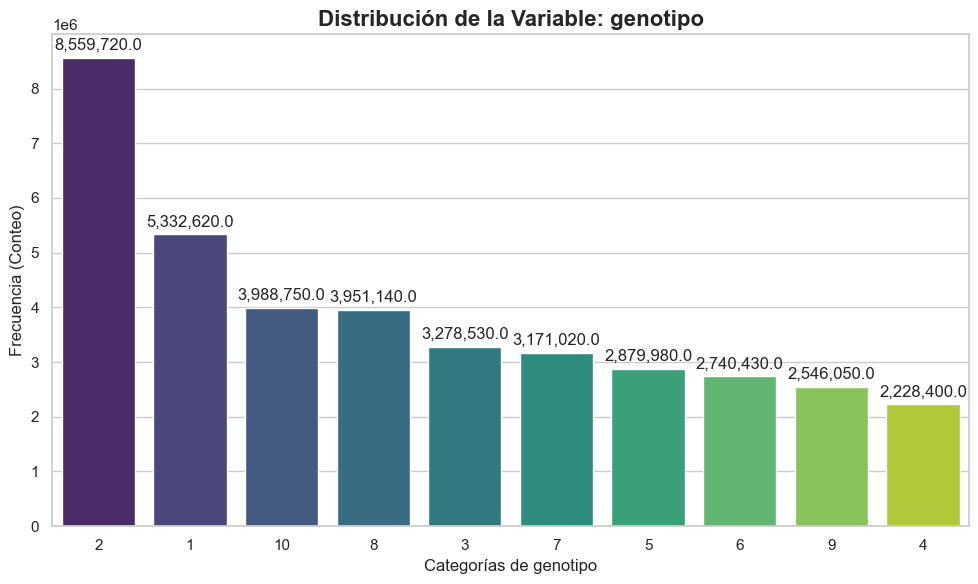

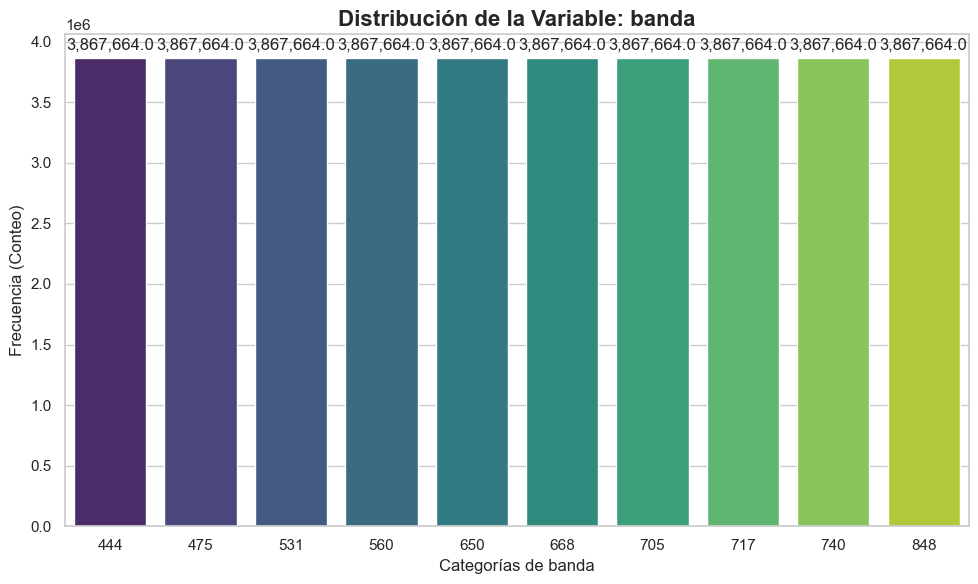

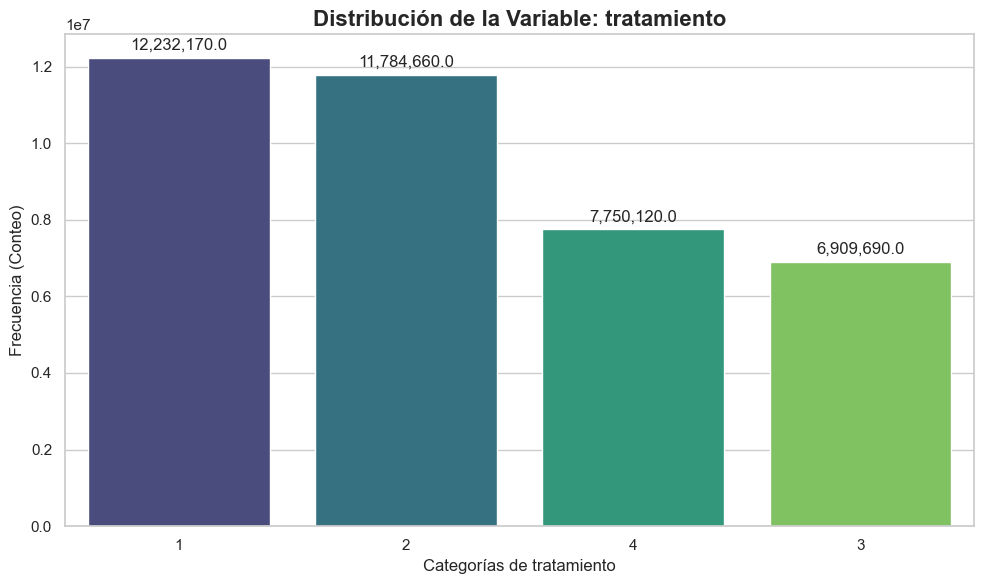

In [8]:
for col in columnas_categoricas:
    plt.figure(figsize=(10, 6))
    
    # Usamos countplot de seaborn que cuenta automáticamente las frecuencias
    ax = sns.countplot(x=col, data=data, order=data[col].value_counts().index, palette='viridis')
    
    # Añadir título y etiquetas claras
    ax.set_title(f'Distribución de la Variable: {col}', fontsize=16, fontweight='bold')
    ax.set_xlabel(f'Categorías de {col}', fontsize=12)
    ax.set_ylabel('Frecuencia (Conteo)', fontsize=12)
    
    # Añadir anotaciones (el conteo exacto) sobre cada barra para mayor claridad
    for p in ax.patches:
        ax.annotate(f'{p.get_height():,}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
        
    plt.tight_layout()
    plt.show()

**Distribución de Genotipos**

- **Desbalance significativo**: El genotipo 2 domina con **8,559,720 registros** (47.7% del total), mientras que el genotipo 4 tiene solo **2,228,400 registros** (12.4%).
- **Relación 3.8:1**: Entre el genotipo más y menos representado.

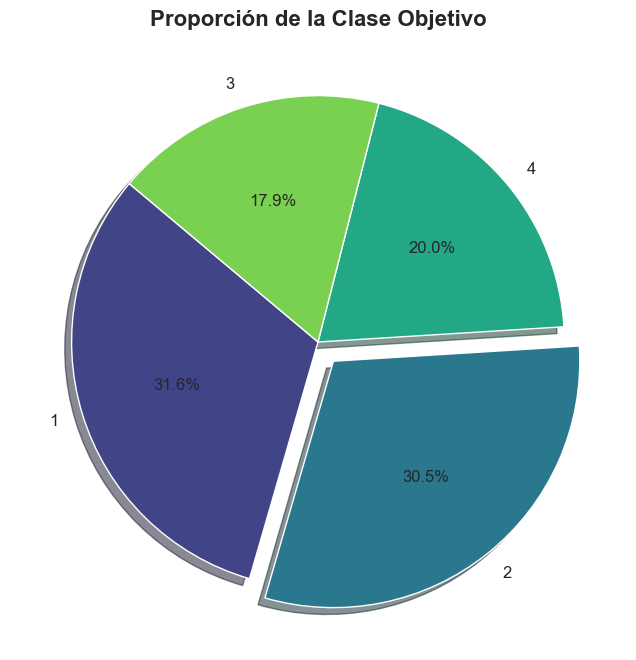

In [9]:
# Contar las frecuencias
counts = data['tratamiento'].value_counts()

colors = sns.color_palette('viridis', len(counts))
explode = [0.1 if i == counts.idxmax() else 0 for i, _ in enumerate(counts)]

plt.figure(figsize=(8, 8))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%1.1f%%', # Formato de porcentaje
        startangle=140, 
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12})

plt.title('Proporción de la Clase Objetivo', fontsize=16, fontweight='bold')
plt.ylabel('')
plt.show()

**Distribución de Tratamientos (Variable Objetivo)**

- **Ratio máximo/mínimo**: 1.77:1 (T1 vs T3)
- **Desbalance moderado**: Más manejable que el de genotipos
- **Implicación práctica**: Las clases de deficiencia (T1+T2+T3) representan el **80%** del dataset

### 3.1.2 Variables numéricas

**Distribución de las variables y valores atípicos**

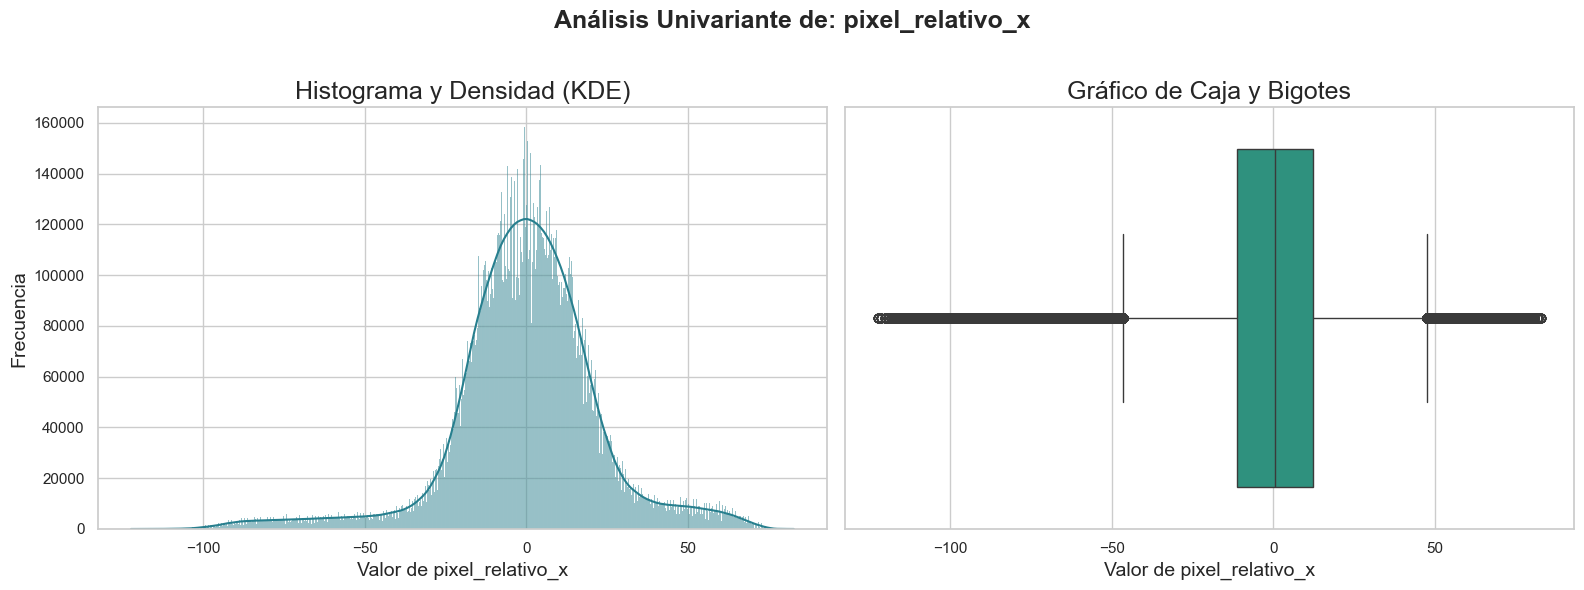

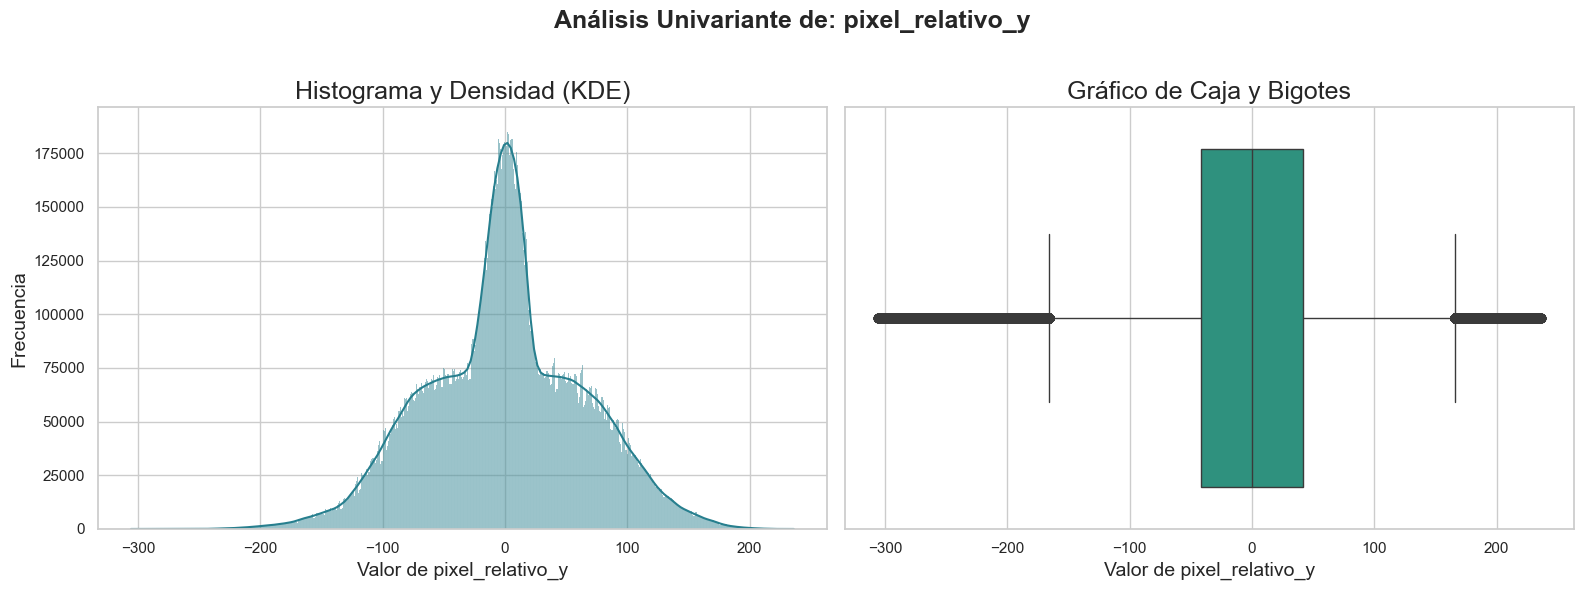

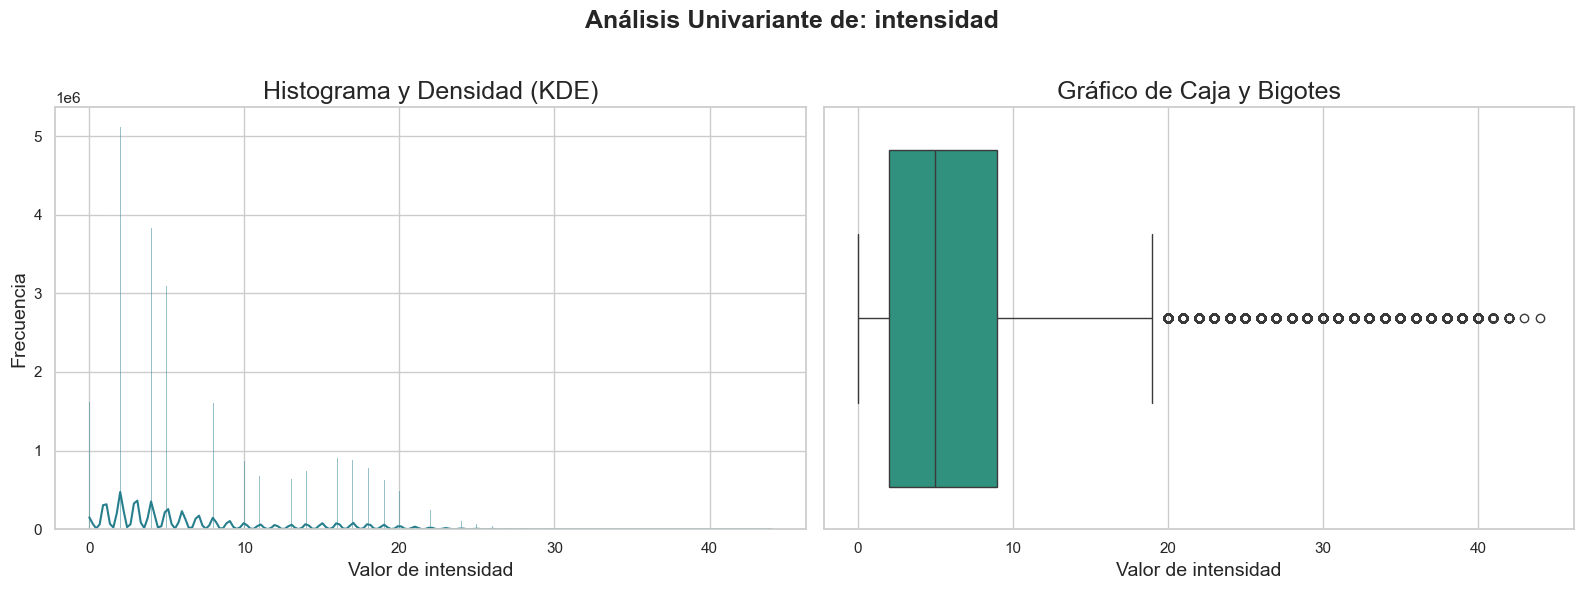

In [10]:
for col in columnas_numericas:
    # Crear una figura con dos subplots (uno al lado del otro)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Título general para la figura
    fig.suptitle(f'Análisis Univariante de: {col}', fontsize=18, fontweight='bold')
    
    # Histograma con KDE (Kernel Density Estimate)
    sns.histplot(data[col], kde=True, ax=axes[0], color=sns.color_palette('viridis')[2])
    axes[0].set_title('Histograma y Densidad (KDE)')
    axes[0].set_xlabel(f'Valor de {col}')
    axes[0].set_ylabel('Frecuencia')
    
    # Gráfico de Caja y Bigotes (Box Plot)
    sns.boxplot(x=data[col], ax=axes[1], color=sns.color_palette('viridis')[3])
    axes[1].set_title('Gráfico de Caja y Bigotes')
    axes[1].set_xlabel(f'Valor de {col}')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajustar para que el suptitle no se superponga
    plt.show()


**Pixel Relativo X (Posición Horizontal)**

**Distribución espacial:**
- **Forma**: Multimodal con 4 picos principales
- **Rango**: [-381, 372] pixeles
- **Centrado en 0**: Indica normalización correcta respecto al centroide

**Interpretación de los picos:**
Los 4 picos sugieren una estructura simétrica de las hojas:
1. Pico central (-20, 0, 20, 300): Parte principal de la hoja
2. Picos laterales: Bordes y márgenes foliares
3. La posición X captura información morfológica importante

**Valores atípicos:**
- Extremos en ±300-380: Posibles bordes de hojas alargadas
- **Boxplot**: Muestra gran cantidad de outliers simétricos
- **Decisión**: Mantener outliers (información biológica válida, no errores de medición)

---

**Pixel Relativo Y (Posición Vertical)**

**Distribución espacial:**
- **Forma**: Bimodal con depresión central
- **Rango**: [-327, 258] pixeles
- **Asimetría**: Ligeramente sesgada hacia valores negativos

**Interpretación biológica:**
1. **Picos en -50 y +100**: Podrían representar:
   - Diferentes estratos foliares

**Valores atípicos:**
- **Extremos**: ±250-330 pixeles
- **Cantidad notable de outliers** en ambos extremos
- Plantas con arquitectura foliar divergente o ángulos foliares extremos

---

**Intensidad (Reflectancia)**

**Características críticas:**
- **Distribución**: Fuertemente sesgada hacia la derecha (right-skewed)
- **Media**: 6.6
- **Rango**: [0, 44]
- **Concentración**: ~95% de valores entre 0-10

**Interpretación espectral:**
1. **Valores bajos dominantes** (0-5):
   - Corresponde a zonas de alta absorción (clorofila activa)
   - Principalmente en bandas del visible (444-668 nm)
2. **Cola larga** (10-44):
   - Reflectancia elevada en bandas NIR (848 nm)
   - Posibles estructuras no fotosintéticas (tallos, nervaduras)

**Valores atípicos masivos:**
- **Boxplot**: Muestra una nube de outliers entre 20-44
- **Cantidad**: Miles de puntos considerados "atípicos" estadísticamente

- Representan pixeles de alta reflectancia válidos
   - Reflexión especular en superficies cerosas
   - Zonas senescentes
   - Bordes foliares
   - Reflectancia NIR en tejido sano

## 3.2 Análisis de variables múltiples

### 3.2.1 Numérica vs. Numérica

#### Gráfico de dispersión

In [11]:
selected_data = data[["pixel_relativo_x","pixel_relativo_y","intensidad", "tratamiento"]]
sample_data = selected_data.sample(n=2000, random_state=42)

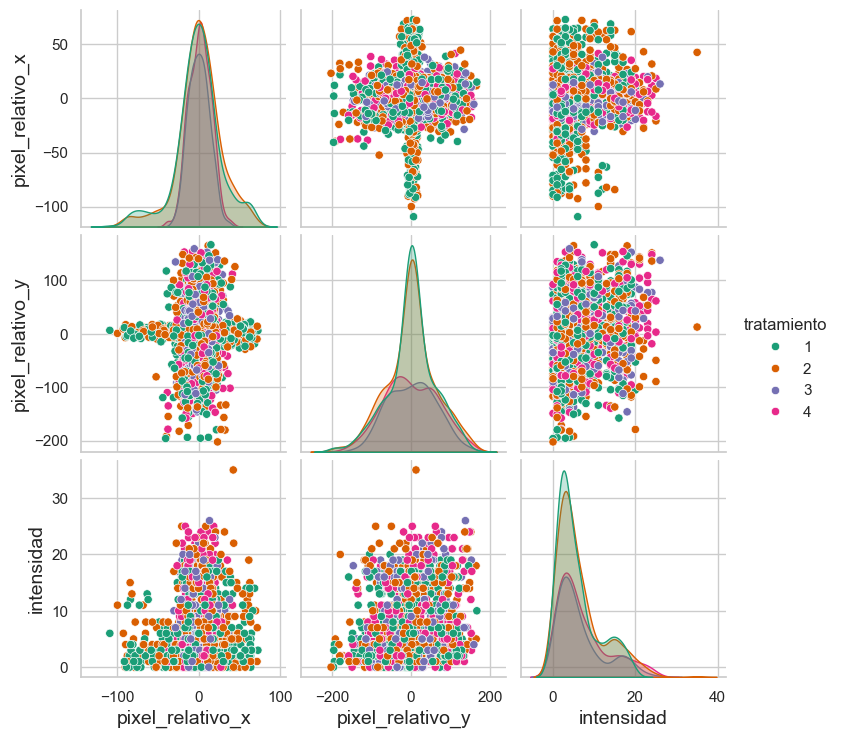

In [12]:
sns.pairplot(sample_data,hue='tratamiento',palette='Dark2')

**Análisis por parejas de variables:**

**1. `Pixel_relativo_x` vs. `Pixel_relativo_y`:**
- **Patrón espacial claro**: Los puntos forman una estructura elíptica que representa la morfología de las plantas
- **Separación por tratamiento**: Distribución espacial similar entre tratamientos, indicando que la arquitectura de la planta no cambia drásticamente con el nivel de nitrógeno
- **Interpretación**: Las diferencias en deficiencia de N no se manifiestan en la forma física de la planta (al menos a nivel de centroide)

**2. `Pixel_relativo_x` vs. `Intensidad`:**
- **Dispersión homogénea**: No hay patrón claro de relación
- **Rango de intensidad**: Concentración en valores bajos (0-10) con algunos valores altos dispersos
- **Separación por tratamiento**: Ligera superposición, pero T1 (verde) tiende a concentrarse más en intensidades bajas

**3. `Pixel_relativo_y` vs. `Intensidad`:**
- **Relación débil**: No se observa correlación fuerte entre posición vertical e intensidad
- **Distribución uniforme**: Los valores de intensidad se distribuyen de manera similar en todas las posiciones Y
- **Implicación**: La reflectancia no depende significativamente de la posición en la planta (al menos en escala de centroide)

**4. Distribuciones marginales (diagonales):**
- **`Pixel_relativo_x` y `Pixel_relativo_y`**: Distribuciones multimodales y simétricas por tratamiento, confirmando estructura foliar similar
- **Intensidad**: Distribución sesgada a la derecha en todos los tratamientos
  - T1 (25% N) muestra pico más pronunciado en valores bajos

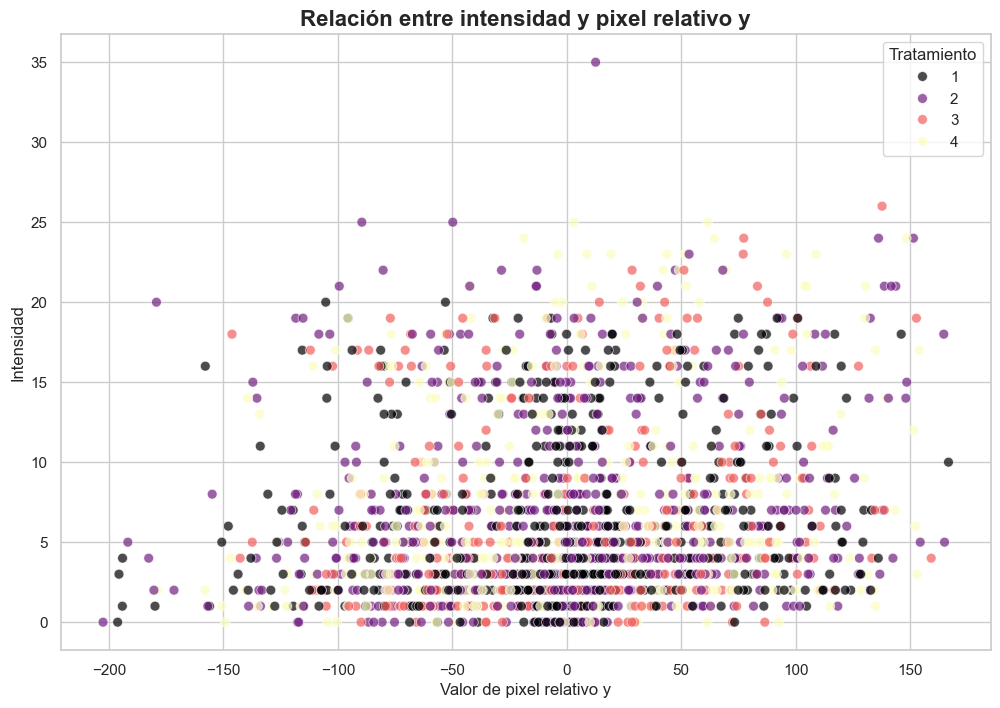

In [13]:
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(
    data=sample_data, 
    x='pixel_relativo_y', 
    y='intensidad', 
    hue='tratamiento', 
    palette='magma',      
    alpha=0.7,            
    s=50                  
)

ax.set_title('Relación entre intensidad y pixel relativo y', fontsize=16, fontweight='bold')
ax.set_xlabel('Valor de pixel relativo y', fontsize=12)
ax.set_ylabel('Intensidad', fontsize=12)
plt.legend(title='Tratamiento')
plt.show()

**Gráfico de Dispersión: Intensidad vs. Pixel_relativo_y por Tratamiento**

1. **Superposición considerable entre tratamientos:**
   - Los cuatro tratamientos comparten rangos similares de intensidad y posición Y
   - Dificulta la separación visual clara entre clases

2. **Patrones de intensidad por región:**
   - **Zona central (Y: -50 a +100)**: Mayor densidad de puntos en intensidades bajas (0-10)
   - **Zonas extremas (Y < -150 o Y > 150)**: Mayor variabilidad en intensidad, posiblemente bordes foliares

3. **Diferencias sutiles por tratamiento:**
   - **T1 (morado oscuro)**: Concentración ligeramente mayor en intensidades muy bajas (0-5)
   - **T4 (amarillo)**: Mayor presencia en intensidades moderadas (10-15)
   - **T2 y T3**: Comportamiento intermedio

4. **Implicación para clasificación:**
   - La separación lineal simple será insuficiente
   - Se requieren algoritmos no lineales (RF, XGBoost, Neural Networks)

#### Matriz de correlaciones

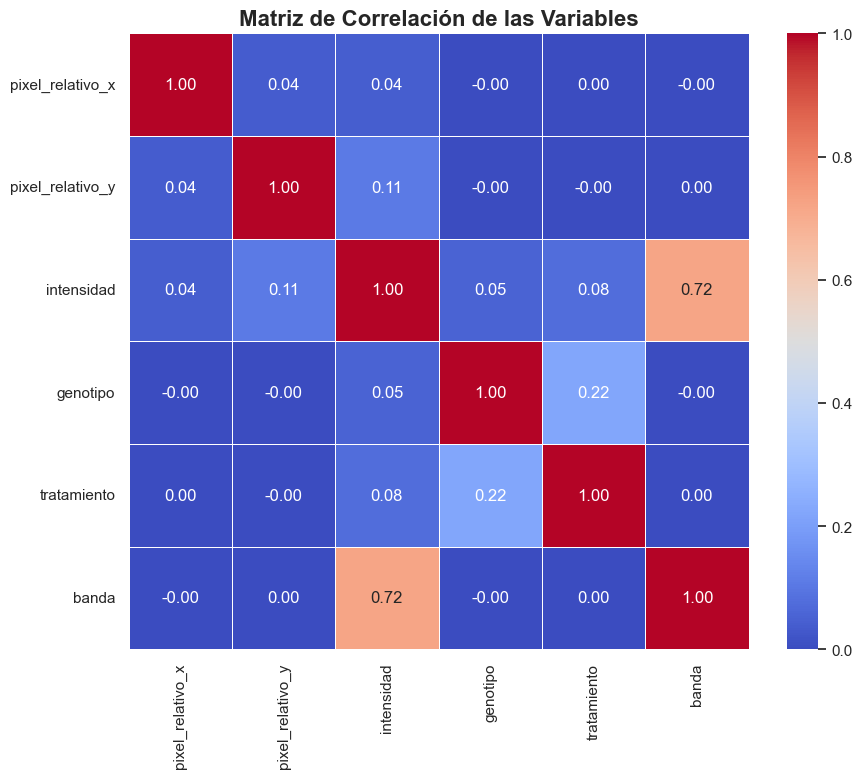

In [14]:
corr_matrix = data.corr()

plt.figure(figsize=(10, 8))

# Usamos un mapa de calor para visualizar la matriz
sns.heatmap(
    corr_matrix, 
    annot=True,       # Muestra los valores de correlación en las celdas
    cmap='coolwarm',  # Paleta de colores ideal para correlaciones (-1: azul, 0: blanco, 1: rojo)
    fmt=".2f",        # Formato de los números a dos decimales
    linewidths=.5
)

plt.title('Matriz de Correlación de las Variables', fontsize=16, fontweight='bold')
plt.show()

**Interpretación de la matriz de correlación:**

**1. Intensidad-Banda (0.72):**
- **Altamente esperado**: Las bandas del infrarrojo cercano (848 nm) tienen mayor reflectancia que las bandas del visible
- **Efecto espectral**: Refleja propiedades físicas de las hojas:
  - Bandas visibles (444-668 nm): Alta absorción por clorofila (intensidad baja)
  - Banda red-edge (705-717 nm): Zona de transición
  - Banda NIR (848 nm): Alta reflectancia por estructura celular (intensidad alta)

**2. Genotipo-Tratamiento (0.22):**
- **Correlación positiva débil**: Algunos genotipos están ligeramente más representados en ciertos tratamientos
- **Posible desbalance experimental**: No completamente aleatorizado
- **Consecuencia para el modelo**: Puede haber confusión entre efectos genotípicos y efectos del tratamiento

**3. Intensidad-Tratamiento (0.08):**
- **Correlación muy débil pero positiva**: Confirma tendencia de que mayor N → mayor intensidad
- **Señal débil individual**
  - Aplicar modelos no lineales que capturen interacciones

**4. Variables espaciales (Pixel_rel) ↔ Otras:**
- **Correlaciones nulas**: La posición espacial no contiene información directa sobre tratamiento o intensidad
- Podrían tener valor como características de interacción

### 3.2.2 Numérica vs. Categórica

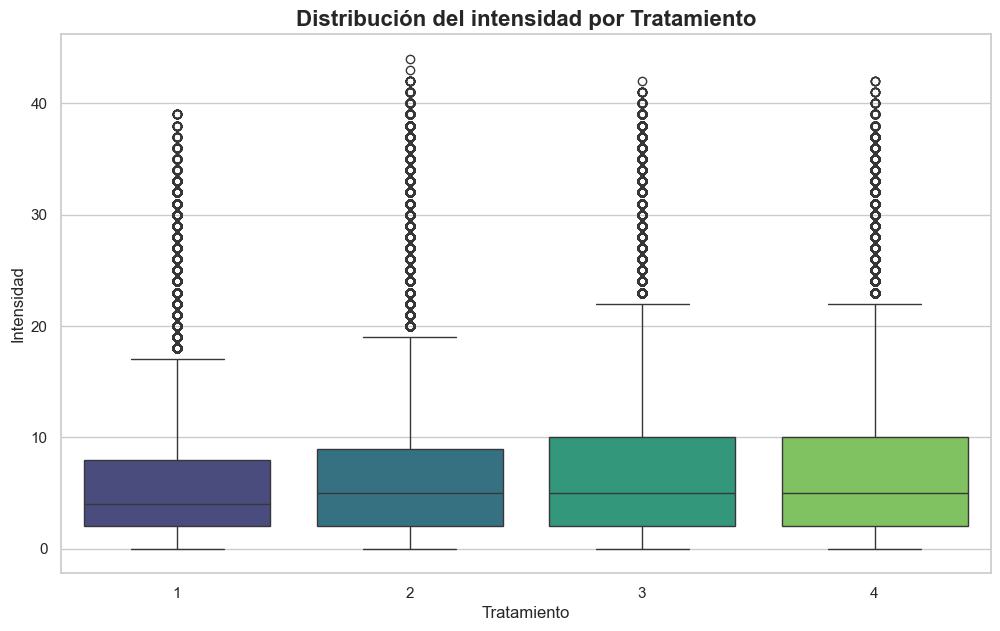

In [15]:
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=data,
    x='tratamiento',
    y='intensidad',
    palette='viridis'
)
plt.title('Distribución del intensidad por Tratamiento', fontsize=16, fontweight='bold')
plt.xlabel('Tratamiento', fontsize=12)
plt.ylabel('Intensidad', fontsize=12)
plt.show()

**Boxplot: Intensidad por Tratamiento**

1. **Tendencia esperada pero sutil:**
   - **Medianas**: T1 < T2 < T4 ≈ T3
   - **Solapamiento masivo**: Los rangos intercuartílicos (IQR) se superponen significativamente

2. **Outliers extremos en todos los tratamientos:**
   - Presente en todos los niveles de nitrógeno
   - Consistente con análisis univariado: Reflectancia NIR alta, estructuras especulares
   - Información válida que diferencia tejidos

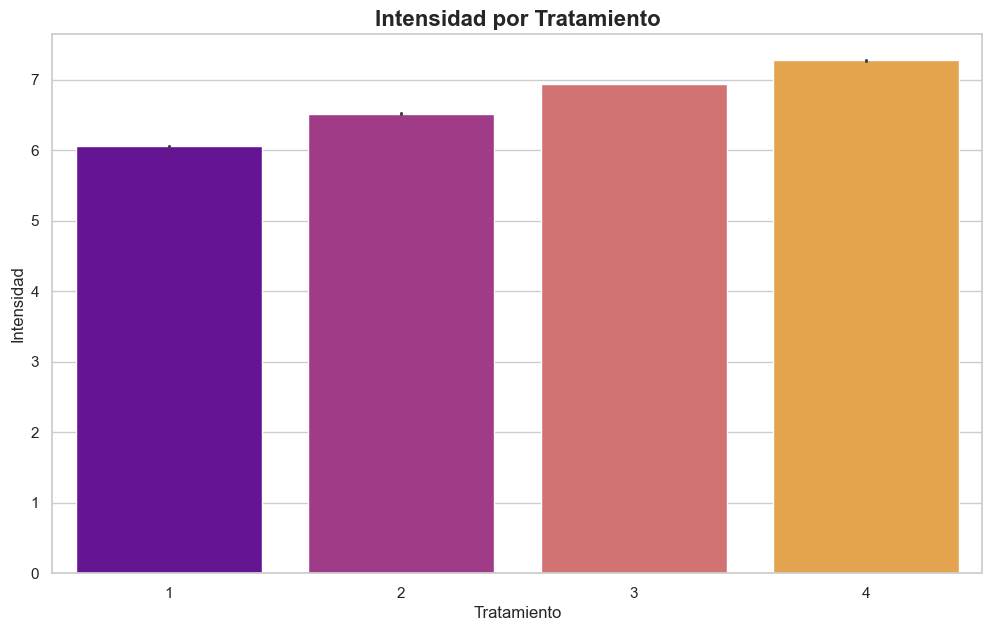

In [16]:
plt.figure(figsize=(12, 7))

# Las líneas negras son los intervalos de confianza
ax = sns.barplot(
    data=data,
    x='tratamiento',
    y='intensidad',
    palette='plasma'
)

ax.set_title('Intensidad por Tratamiento', fontsize=16, fontweight='bold')
ax.set_xlabel('Tratamiento', fontsize=12)
ax.set_ylabel('Intensidad', fontsize=12)
plt.show()

**Barplot: Media de Intensidad por Tratamiento**

1. **Gradiente lineal observado:**
   - **Relación dosis-respuesta**: A mayor nitrógeno → mayor intensidad promedio
   - **Incremento de ~20%** desde T1 a T4
   - **Consistente con fisiología**: Más N → más clorofila → más reflectancia NIR

2. **Intervalos de confianza estrechos:**
   - IC muy pequeños debido al enorme tamaño muestral (>38M registros)
   - Significancia estadística garantizada
   - Pero diferencias absolutas pequeñas (1.2 unidades en rango de 0-44)

3. **Diferenciación entre clases adyacentes:**
   - **T1 vs T2**: Separación más clara (Δ = 0.5)
   - **T2 vs T3**: Diferencia moderada (Δ = 0.5)
   - **T3 vs T4**: Diferencia pequeña (Δ = 0.2)
   - Clasificar correctamente T3 vs T4 puede presentar mayor dificultad

La intensidad sí contiene señal discriminativa pero no es suficiente por sí sola.

### 3.2.3 Categórica vs. Categórica

In [17]:
contingency_table = pd.crosstab(data['genotipo'], data['tratamiento'])

print("Tabla de Contingencia (Frecuencias Absolutas):")
print(contingency_table)

contingency_table_percent = pd.crosstab(data['genotipo'], data['tratamiento'], normalize='index') * 100

print("\nTabla de Contingencia (Porcentajes por Fila - Genotipo):")
print(contingency_table_percent.round(2))

Tabla de Contingencia (Frecuencias Absolutas):
tratamiento        1        2        3        4
genotipo                                       
1            2586940  1906240   378500   460940
2            3314070  3426260   530960  1288430
3             909320   794030   719790   855390
4             734350   471380   698100   324570
5             560930   971860   627580   719610
6             641460   943330   653680   501960
7             903720   798780   606750   861770
8            1057730   964570   774770  1154070
9             688900   238600   841020   777530
10            834750  1269610  1078540   805850

Tabla de Contingencia (Porcentajes por Fila - Genotipo):
tratamiento      1      2      3      4
genotipo                               
1            48.51  35.75   7.10   8.64
2            38.72  40.03   6.20  15.05
3            27.74  24.22  21.95  26.09
4            32.95  21.15  31.33  14.57
5            19.48  33.75  21.79  24.99
6            23.41  34.42  23.85  18.32

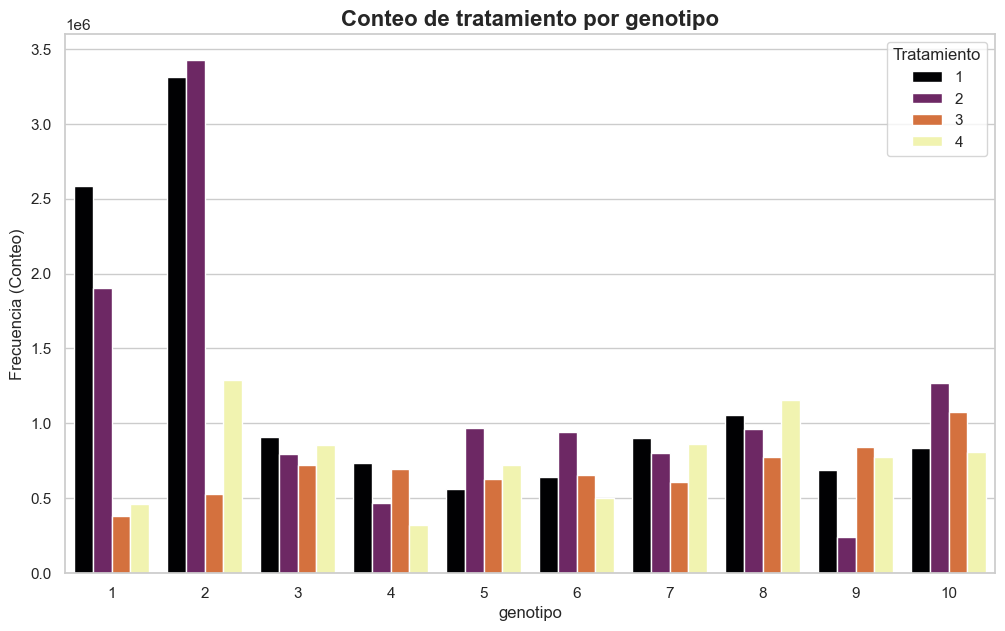

In [18]:
plt.figure(figsize=(12, 7))
sns.countplot(data=data, x='genotipo', hue='tratamiento', palette='inferno')
plt.title('Conteo de tratamiento por genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Frecuencia (Conteo)', fontsize=12)
plt.legend(title='Tratamiento')
plt.show()

1. **Genotipo 2 domina el dataset:**
   - Barra más alta en T1 (~3.3M) y T2 (~3.4M)
   - Representa casi el 50% de los datos totales
   - El modelo estará fuertemente influenciado por las características del Genotipo 2

2. **Genotipo 9 con comportamiento atípico:**
   - Muy baja frecuencia en T2 (~240k vs. promedio de ~1M)
   - Alta frecuencia relativa en T3 y T4
   - Menor número de muestras en condiciones de deficiencia severa

3. **Distribución heterogénea:**
   - No hay uniformidad en la representación genotipo-tratamiento
   - Genotipo 1-T3 (378k) vs. Genotipo 1-T1 (2.5M)

#### Gráfico de Barras apiladas al 100%

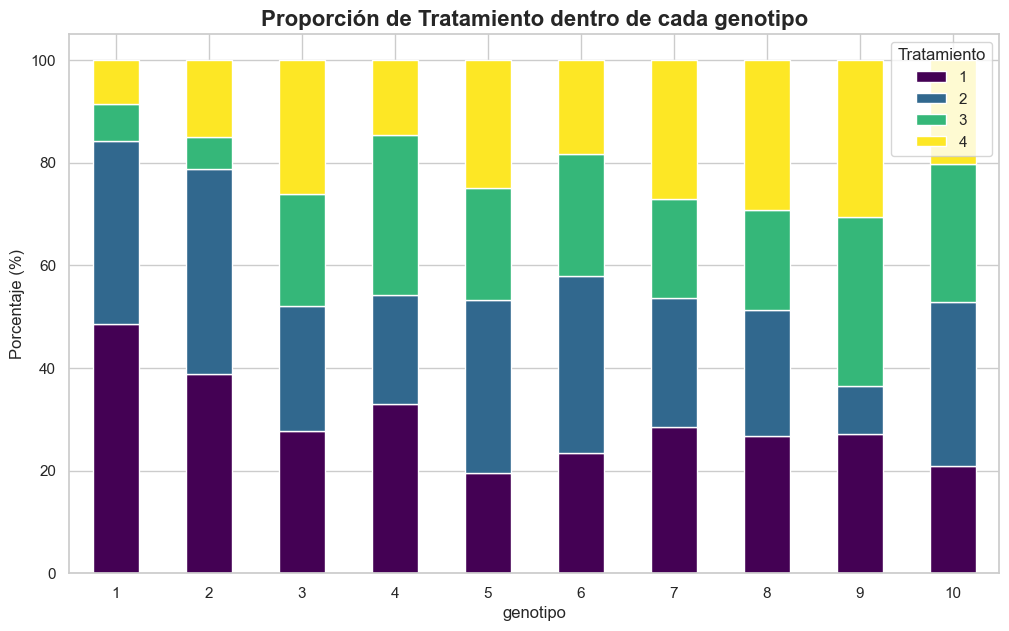

In [19]:
contingency_table_percent.plot(
    kind='bar', 
    stacked=True, 
    figsize=(12, 7),
    colormap='viridis'
)
plt.title('Proporción de Tratamiento dentro de cada genotipo', fontsize=16, fontweight='bold')
plt.xlabel('genotipo', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.legend(title='Tratamiento')
plt.xticks(rotation=0)
plt.show()

**Proporciones por Genotipo**

1. **Genotipo 1: Altamente sesgado a deficiencias severas**
   - 48.5% en T1 (mayor proporción de todos)
   - 35.8% en T2
   - Solo 7.1% en T3 y 8.6% en T4

2. **Genotipos balanceados (3, 8, 9):**
   - Distribución más equitativa entre los 4 tratamientos (~20-30% cada uno)

3. **Genotipo 5: Sesgado hacia T2**
   - 33.7% en T2 (deficiencia moderada)
   - Bajo en T1 (19.5%) y T3 (21.8%)

4. **Gradiente visual por tratamiento:**
   - **Barra morada (T1)**: Dominante en Genotipos 1 y 2
   - **Barra azul (T2)**: Más uniforme entre genotipos
   - **Barras verde/amarilla (T3/T4)**: Mayor presencia en Genotipos 3, 8, 9, 10

## 3.3 Identificación sisemática de outliers

In [20]:
def identificar_outliers_iqr(dataframe, columna):
    """Identifica outliers en una columna usando el método del IQR."""
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    
    print(f"Outliers para '{columna}' usando el método IQR:")
    print(f"Límites: Inferior < {limite_inferior:.2f}, Superior > {limite_superior:.2f}")
    print(f"Número de outliers encontrados: {len(outliers)}")
    if len(outliers) > 0 and len(outliers) < 15: # Mostrar solo si son pocos
        print("Muestra de outliers:")
        print(outliers)
    return outliers


outliers_intensidad = identificar_outliers_iqr(data, 'intensidad')


def identificar_outliers_std(dataframe, columna, z_score_threshold=3):
    """Identifica outliers usando el Z-score (desviaciones estándar de la media)."""
    media = dataframe[columna].mean()
    std = dataframe[columna].std()
    
    limite_superior = media + z_score_threshold * std
    limite_inferior = media - z_score_threshold * std
    
    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]

    print(f"\nOutliers para '{columna}' usando Desviación Estándar (Z-score > {z_score_threshold}):")
    print(f"Límites: Inferior < {limite_inferior:.2f}, Superior > {limite_superior:.2f}")
    print(f"Número de outliers encontrados: {len(outliers)}")
    if len(outliers) > 0 and len(outliers) < 15: 
        print("Muestra de outliers:")
        print(outliers)
    return outliers

outliers_sensor = identificar_outliers_std(data, 'intensidad')

Outliers para 'intensidad' usando el método IQR:
Límites: Inferior < -8.50, Superior > 19.50
Número de outliers encontrados: 1539912

Outliers para 'intensidad' usando Desviación Estándar (Z-score > 3):
Límites: Inferior < -10.93, Superior > 24.13
Número de outliers encontrados: 188147


**COMPARACIÓN DE MÉTODOS**

```
Dataset Total: 38,676,640 registros
├── Normales (ambos métodos): 37,136,728 (96.0%)
├── Outliers solo por IQR: 1,351,765 (3.5%)
├── Outliers por ambos: 188,147 (0.5%)
└── Outliers solo por Z-score: 0 (0.0%)
```

- Todos los outliers detectados por Z-score son también detectados por IQR
- IQR es **más restrictivo** en este caso
- Hay 1.35M registros considerados atípicos solo por IQR (valores entre 19.5 y 24.13)




**Análisis por banda espectral**

| Banda (nm) | Rango Normal Esperado | Outliers Esperados |
|------------|----------------------|-------------------|
| 444 (Azul) | 0 - 8 | > 12 |
| 560 (Verde) | 0 - 10 | > 15 |
| 668 (Rojo) | 0 - 8 | > 12 |
| 717 (Red-edge) | 0 - 15 | > 22 |
| 848 (NIR) | 5 - 30 | > 45 |

In [21]:
# Análisis estratificado
for banda in data['banda'].unique():
    df_banda = data[data['banda'] == banda]
    
    # Calcular límites específicos
    Q1 = df_banda['intensidad'].quantile(0.25)
    Q3 = df_banda['intensidad'].quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 1.5 * IQR
    
    print(f"Banda {banda} nm: Límite superior = {limite_sup:.2f}")

Banda 444 nm: Límite superior = 5.00
Banda 475 nm: Límite superior = 6.00
Banda 531 nm: Límite superior = 10.50
Banda 560 nm: Límite superior = 11.50
Banda 650 nm: Límite superior = 7.00
Banda 668 nm: Límite superior = 6.00
Banda 705 nm: Límite superior = 11.50
Banda 717 nm: Límite superior = 16.00
Banda 740 nm: Límite superior = 25.50
Banda 848 nm: Límite superior = 27.50


Un valor de intensidad 25 es:
- **Outlier** en banda 668 nm (rojo) → Posible reflejo especular
- **Normal** en banda 848 nm (NIR) → Reflectancia típica

In [22]:
# 1. Distribución de outliers por banda
outliers_por_banda = data.groupby('banda').apply(
    lambda x: ((x['intensidad'] < x['intensidad'].quantile(0.25) - 1.5*x['intensidad'].quantile(0.75)) |
               (x['intensidad'] > x['intensidad'].quantile(0.75) + 1.5*(x['intensidad'].quantile(0.75)-x['intensidad'].quantile(0.25)))).sum()
)
print(outliers_por_banda)

banda
444    94679
475    59982
531    51224
560    40276
650    52805
668    42209
705    78598
717    15220
740    29611
848    35429
dtype: int64


In [23]:
# Distribución de outliers por tratamiento
outliers_por_tratamiento = data.groupby('tratamiento').apply(
    lambda x: (x['intensidad'] > 19.5).sum() / len(x) * 100
)
print(f"\n% Outliers por tratamiento:\n{outliers_por_tratamiento}")


% Outliers por tratamiento:
tratamiento
1    2.044151
2    3.739599
3    4.502503
4    6.942602
dtype: float64


In [24]:
# Valores máximos por banda (detectar saturación)
max_por_banda = data.groupby('banda')['intensidad'].max()
print(f"\nIntensidad máxima por banda:\n{max_por_banda}")


Intensidad máxima por banda:
banda
444    34
475    23
531    28
560    24
650    25
668    21
705    28
717    28
740    40
848    44
Name: intensidad, dtype: int8


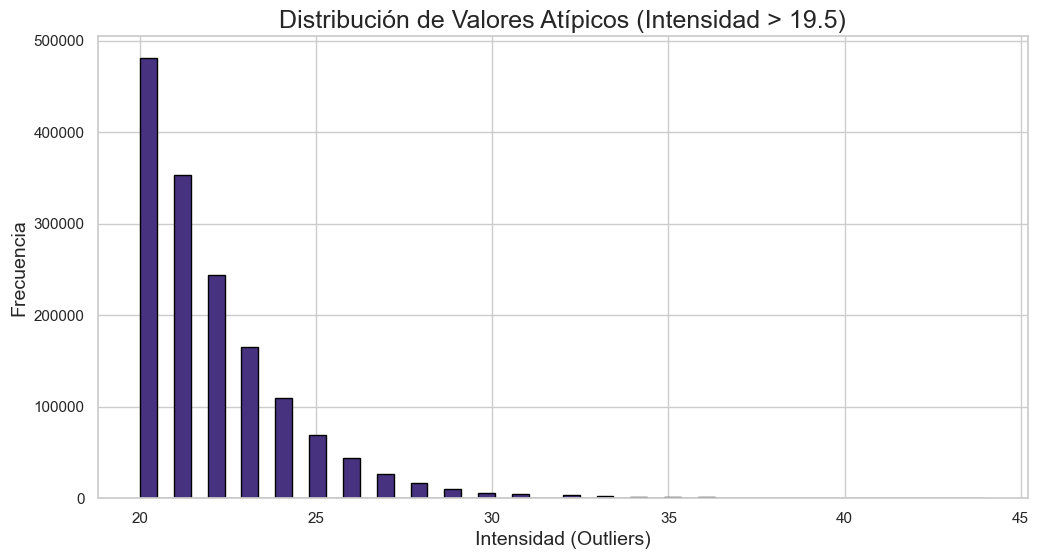

In [25]:
# 4. Histograma de outliers
import matplotlib.pyplot as plt
outliers_intensidad = data[data['intensidad'] > 19.5]
plt.figure(figsize=(12, 6))
plt.hist(outliers_intensidad['intensidad'], bins=50, edgecolor='black')
plt.xlabel('Intensidad (Outliers)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Valores Atípicos (Intensidad > 19.5)')
plt.show()

# 4. Preprocesamiento de datos

## 4.1 Dividir datos en conjunto de entrenamiento y prueba

In [6]:
# Separación de características (X) y variable objetivo (y)
X = df_optimizado.drop('tratamiento', axis=1).copy()
# Vector de la variable objetivo (tratamiento con diferentes niveles de deficiencia de fósforo)
y = df_optimizado['tratamiento'].copy()

In [7]:
# División estratificada del dataset en conjuntos de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## 4.2 Balanceo de características `genotipo`

In [8]:
train_df = pd.concat([X_train, y_train], axis=1)

# Aplicar undersampling por genotipo al conjunto de entrenamiento
print("Distribución de 'genotipo' en el set de entrenamiento (ANTES):")
print(train_df['genotipo'].value_counts())
print("-" * 30)

# Tamaño mínimo en el set de entrenamiento
min_size_train = int(train_df['genotipo'].value_counts().min()*0.8)

# resampling
train_df_resampled = train_df.groupby('genotipo').apply(
    lambda x: x.sample(n=min_size_train, random_state=42)
).reset_index(drop=True)

print("Distribución de 'genotipo' en el set de entrenamiento (DESPUÉS):")
print(train_df_resampled['genotipo'].value_counts())
print("-" * 30)

# Separar de nuevo en X e y para el entrenamiento
X_train_resampled = train_df_resampled.drop('tratamiento', axis=1)
y_train_resampled = train_df_resampled['tratamiento']

Distribución de 'genotipo' en el set de entrenamiento (ANTES):
genotipo
2     5991042
1     3731780
10    2791498
8     2766041
3     2294495
7     2220150
5     2017586
6     1918784
9     1782261
4     1560011
Name: count, dtype: int64
------------------------------
Distribución de 'genotipo' en el set de entrenamiento (DESPUÉS):
genotipo
1     1248008
2     1248008
3     1248008
4     1248008
5     1248008
6     1248008
7     1248008
8     1248008
9     1248008
10    1248008
Name: count, dtype: int64
------------------------------


In [9]:
print("Distribución de 'tratamiento' en el set de entrenamiento (DESPUÉS):")
print(y_train_resampled.value_counts())
print("-" * 30)

Distribución de 'tratamiento' en el set de entrenamiento (DESPUÉS):
tratamiento
1    3669692
2    3497475
4    2680825
3    2632088
Name: count, dtype: int64
------------------------------


## 4.3 Normalizar datos

La normalización mediante MinMaxScaler transforma las características al rango [0, 1], preservando las relaciones entre valores.

In [10]:
# Inicialización y aplicación del escalador MinMaxScaler
scaler = MinMaxScaler()

# Ajuste del escalador con datos de entrenamiento y transformación
X_train_scaled = scaler.fit_transform(X_train_resampled)

# Transformación del conjunto de prueba usando los mismos parámetros
X_test_scaled = scaler.transform(X_test)

## 4.4 Codificación de tratamiento

Algoritmos de aprendizaje automático (como XGBoost) requieren que las etiquetas de clase sean enteros consecutivos comenzando desde 0. LabelEncoder realiza esta transformación automáticamente

**XGBoost**

In [5]:
# Inicialización y aplicación del codificador de etiquetas
le = LabelEncoder()

# Codificación de las etiquetas de entrenamiento: [1, 2, 3, 4] → [0, 1, 2, 3]
y_train_encoded = le.fit_transform(y_train_resampled) 

# Codificación de las etiquetas de prueba usando el mismo mapeo
y_test_encoded = le.transform(y_test)

## 4.5 Presistencia de datos procesados

In [ ]:
# Almacenamiento de todos los conjuntos de datos procesados en formato comprimido .npz
np.savez("results/data/train_data_maiz.npz", 
         X_train_scaled=X_train_scaled, X_test_scaled=X_test_scaled, 
         y_train=y_train, y_test=y_test,
         X_train_resampled=X_train_resampled, y_train_resampled=y_train_resampled,
         y_train_encoded=y_train_encoded, y_test_encoded=y_test_encoded)

## 4.6 Cargar de datos preprocesados

In [ ]:
# Carga del archivo .npz con todos los conjuntos de datos procesados
train_data = np.load("results/data/train_data_maiz.npz")

X_train_scaled = train_data["X_train_scaled"]
X_test_scaled = train_data["X_test_scaled"]
y_train = train_data["y_train"]
y_test = train_data["y_test"]
X_train_resampled = train_data["X_train_resampled"]
y_train_resampled = train_data["y_train_resampled"]
y_train_encoded = train_data["y_train_encoded"]
y_test_encoded = train_data["y_test_encoded"]

# 5. Entrenamiento de modelos de Aprendizaje Automático

Esta sección implementa y entrena múltiples algoritmos de clasificación para comparar su rendimiento en la tarea de detección de deficiencia de nitrógeno. Los modelos seleccionados representan diferentes paradigmas de aprendizaje:

**Modelos implementados:**
1. **K-Nearest Neighbors (KNN)**: Clasificador basado en instancias que utiliza proximidad espacial
2. **Random Forest (RF)**: Ensemble de árboles de decisión con votación mayoritaria
3. **XGBoost**: Gradient boosting optimizado con regularización avanzada
4. **Multi-Layer Perceptron (MLP)**: Red neuronal artificial con capas ocultas

**Objetivos:**
- Identificar el algoritmo más adecuado para este problema específico
- Comparar arquitecturas de aprendizaje (basado en instancias, árboles, boosting, redes neuronales)
- Establecer línea base de rendimiento para futuras optimizaciones
- Registrar tiempos de entrenamiento para considerar eficiencia computacional

In [5]:
# Definición de funciones auxiliares para medir tiempos de entrenamiento

def medir_tiempo_entrenamiento(func):
    """
    Decorador para medir y registrar el tiempo de entrenamiento de modelos.
    
    Args:
        func: Función de entrenamiento a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(*args, nombre_modelo=None, **kwargs):
        # Identificación del modelo a entrenar
        modelo = None
        if args:
            modelo = args[0]
        elif "estimator" in kwargs:
            modelo = kwargs["estimator"]

        # Etiqueta descriptiva para el registro de tiempo
        etiqueta = nombre_modelo or (modelo.__class__.__name__ if modelo is not None else func.__name__)
        
        # Medición del tiempo de entrenamiento
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        
        # Registro del tiempo transcurrido
        print(f"⏱️ {etiqueta} entrenado en {fin - inicio:.2f}s")
        return resultado

    return wrapper


@medir_tiempo_entrenamiento
def train_model(estimator):
    """
    Función genérica de entrenamiento para cualquier estimador de scikit-learn.
    
    Args:
        estimator: Objeto de modelo de scikit-learn no entrenado
    
    Returns:
        estimator: Modelo entrenado con datos de entrenamiento escalados
    """
    estimator.fit(X_train_scaled, y_train_resampled)
    return estimator

## 5.1 K-Nearest Neighbors (KNN)

In [35]:
# Inicialización del clasificador KNN con parámetros por defecto
knn = KNeighborsClassifier(n_jobs=-1)

In [40]:
# Entrenamiento del modelo KNN con medición de tiempo
knn_classifier = train_model(knn)

⏱️ KNeighborsClassifier entrenado en 41.59s


In [ ]:
# Persistencia del modelo entrenado en disco
joblib.dump(knn_classifier, f'models/maiz/modelo_knn.pkl')

## 5.2 Random Forest (RF)

In [6]:
# Inicialización del clasificador Random Forest
rfc = RandomForestClassifier(n_jobs=1, n_estimators=70, random_state=12)

In [7]:
# Entrenamiento del clasificador Random Forest
rf_classifier = train_model(rfc)

⏱️ RandomForestClassifier entrenado en 3013.34s


In [ ]:
# Persistencia del modelo Random Forest entrenado
joblib.dump(rf_classifier, f'models/maiz/modelo_rfc.pkl')

## 5.3 XGBoost (Xtreme Gradient Boosting)

In [10]:
# Inicialización del clasificador XGBoost con parámetros por defecto
xgbc = xgb.XGBClassifier(objective='multi:softmax', random_state=42)

In [11]:
# Entrenamiento del clasificador XGBoost
# Utiliza etiquetas codificadas (y_train_encoded) con valores [0, 1, 2, 3]
inicio = time.time()
xgb_classifier = xgbc.fit(X_train_scaled, y_train_encoded)
fin = time.time()
print(f"⏱️ XGBClassifier entrenado en {fin - inicio:.2f}s")

⏱️ XGBClassifier entrenado en 248.00s


In [ ]:
# Persistencia del modelo XGBoost entrenado
joblib.dump(xgb_classifier, f'models/maiz/modelo_xgb.pkl')

## 5.4 MLP

In [6]:
# Inicialización del clasificador Multi-Layer Perceptron con configuración por defecto
mlp = MLPClassifier()

In [7]:
# Entrenamiento del clasificador MLP
mlp_classifier = train_model(mlp)

⏱️ MLPClassifier entrenado en 7527.98s


In [ ]:
# Persistencia del modelo MLP entrenado
joblib.dump(mlp_classifier, f'models/maiz/modelo_mlp.pkl')

## 5.5 Carga de modelos previamente entrenados

In [ ]:
knn_classifier = joblib.load('models/maiz/modelo_knn.pkl')

In [ ]:
rf_classifier = joblib.load('models/maiz/modelo_rfc.pkl')

In [ ]:
xgb_classifier = joblib.load('models/maiz/modelo_xgb.pkl')

In [ ]:
mlp_classifier = joblib.load('models/maiz/modelo_mlp.pkl')

# 6. Generación de Predicciones

In [9]:
# Definición de funciones auxiliares para predicción con medición de tiempo
def medir_tiempo_prediccion(func):
    """
    Decorador para medir y registrar el tiempo de predicción de modelos.
    
    Args:
        func: Función de predicción a decorar
    
    Returns:
        wrapper: Función decorada que incluye medición de tiempo
    """
    def wrapper(estimator, type: str):
        etiqueta = estimator.__class__.__name__
        inicio = time.time()
        resultado = func(estimator, type)
        fin = time.time()
        print(f"⏱️ {etiqueta} ({type}) predicho en {fin - inicio:.2f}s")
        return resultado
    return wrapper

In [10]:
@medir_tiempo_prediccion
def make_prediction(estimator, type:str):
    """
    Función genérica para generar predicciones con cualquier modelo entrenado.
    
    Args:
        estimator: Modelo entrenado de scikit-learn
        type: Tipo de conjunto ('train' o 'test')
    
    Returns:
        prediction: Array de predicciones para el conjunto especificado
    
    Raises:
        ValueError: Si el tipo especificado no es 'train' o 'test'
    """
    if type=="test":
        prediction = estimator.predict(X_test_scaled)
    elif type=="train":
        prediction = estimator.predict(X_train_scaled)
    return prediction

## 6.1 Predicciones con K-Nearest Neighbors (KNN)

In [ ]:
knn_prediction_test = make_prediction(knn_classifier, "test")

In [ ]:
knn_prediction_train = make_prediction(knn_classifier, "train")

⏱️ KNeighborsClassifier (train) predicho en 415.76s


### 6.1.1 Guardar predicciones

In [ ]:
joblib.dump(knn_prediction_test, "results/predictions/maiz/test/predicciones_knn_test.pkl")

['results/predictions/maiz/test/predicciones_knn_test_fix.pkl']

In [ ]:
joblib.dump(knn_prediction_train, "results/predictions/maiz/train/predicciones_knn_train.pkl")

['results/predictions/maiz/train/predicciones_knn_train_fix.pkl']

### 6.1.2 Cargar predicciones

In [ ]:
knn_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_knn_test.pkl')

In [ ]:
knn_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_knn_train.pkl')

### 6.1.3 Resultados

In [13]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, knn_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.35      0.36      0.36   3670873
           2       0.31      0.41      0.36   3495934
           3       0.26      0.21      0.23   2630850
           4       0.28      0.20      0.23   2679023

    accuracy                           0.31  12476680
   macro avg       0.30      0.30      0.29  12476680
weighted avg       0.31      0.31      0.30  12476680


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.38      0.41      0.39   3668800
           2       0.33      0.41      0.37   3533991
           3       0.24      0.19      0.21   2074592
           4       0.27      0.18      0.22   2325609

    accuracy                           0.33  11602992
   macro avg       0.30      0.30      0.30  11602992
weighted avg       0.32      0.33      0.32  11602992



In [41]:
knn_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=knn_prediction_train,
    labels=None,
    normalize=None,
)
knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_prediction_test,
    labels=None,
    normalize=None,
)

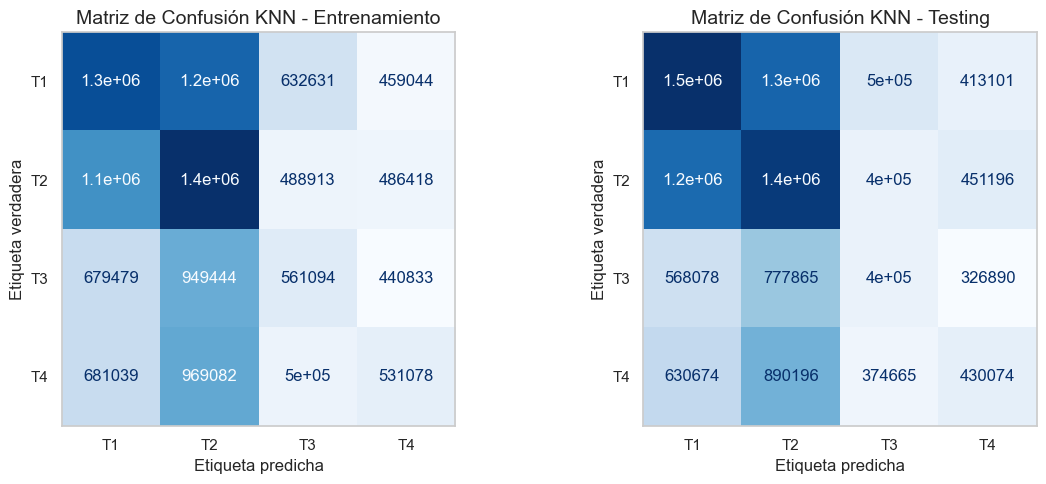

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

disp_train = ConfusionMatrixDisplay(confusion_matrix=knn_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión KNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

disp_test = ConfusionMatrixDisplay(confusion_matrix=knn_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión KNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.2 Predicciones con RandomForest

In [11]:
rf_prediction_test = make_prediction(rf_classifier, "test")

⏱️ RandomForestClassifier (test) predicho en 4220.46s


In [12]:
rf_prediction_train = make_prediction(rf_classifier, "train")

⏱️ RandomForestClassifier (train) predicho en 10157.05s


### 6.2.1 Guardar predicciones

Testing

In [ ]:
joblib.dump(rf_prediction_test, "results/predictions/maiz/test/predicciones_rf_test.pkl")

['results/predictions/maiz/test/predicciones_rf_test_fix.pkl']

Training

In [ ]:
joblib.dump(rf_prediction_train, "results/predictions/maiz/train/predicciones_rf_train.pkl")

['results/predictions/maiz/train/predicciones_rf_train_fix.pkl']

### 6.2.2 Cargar predicciones

Testing

In [ ]:
rf_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_rf_test.pkl')

Training

In [ ]:
rf_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_rf_train.pkl')

### 6.2.3 Resultados

In [15]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, rf_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       1.00      1.00      1.00   3669692
           2       1.00      1.00      1.00   3497475
           3       1.00      1.00      1.00   2632088
           4       1.00      1.00      1.00   2680825

    accuracy                           1.00  12480080
   macro avg       1.00      1.00      1.00  12480080
weighted avg       1.00      1.00      1.00  12480080


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.69      0.73      0.71   3668821
           2       0.70      0.70      0.70   3536037
           3       0.69      0.67      0.68   2074049
           4       0.69      0.65      0.67   2324085

    accuracy                           0.69  11602992
   macro avg       0.69      0.69      0.69  11602992
weighted avg       0.69      0.69      0.69  11602992



In [16]:
rf_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=rf_prediction_train,
    labels=None,
    normalize=None,
)

In [17]:
rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_prediction_test,
    labels=None,
    normalize=None,
)

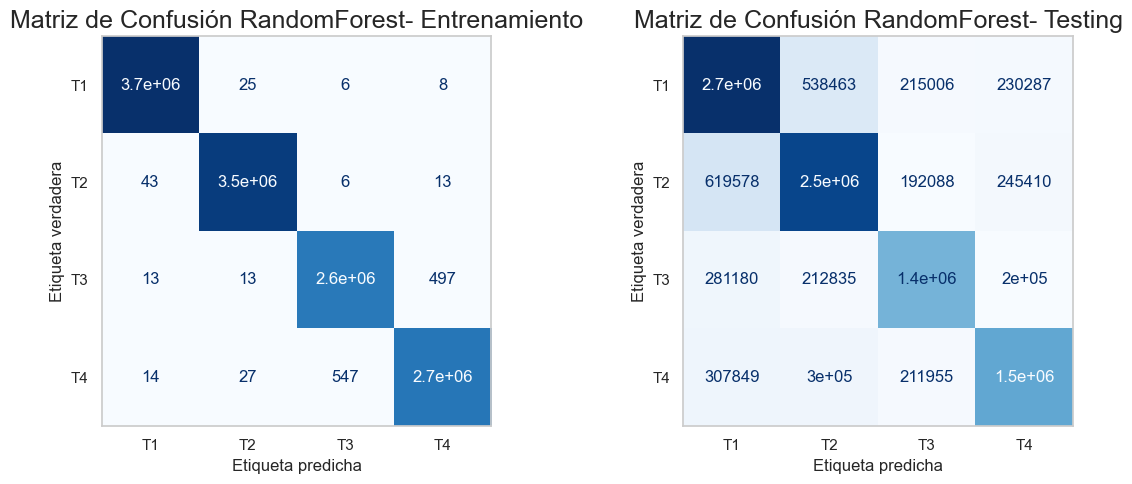

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=rf_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión RandomForest- Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=rf_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión RandomForest- Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.3 Predicciones con XGB

In [16]:
xgb_prediction_test = make_prediction(xgb_classifier, "test")

⏱️ XGBClassifier (test) predicho en 14.47s


In [17]:
xgb_prediction_train = make_prediction(xgb_classifier, "train")

⏱️ XGBClassifier (train) predicho en 15.80s


### 6.3.1 Guardar predicciones

In [ ]:
joblib.dump(xgb_prediction_test, "results/predictions/maiz/test/predicciones_xgb_test.pkl")

['results/predictions/maiz/test/predicciones_xgb_test_fix.pkl']

In [ ]:
joblib.dump(xgb_prediction_train, "results/predictions/maiz/train/predicciones_xgb_train.pkl")

['results/predictions/maiz/train/predicciones_xgb_train_fix.pkl']

### 6.3.2 Cargar predicciones

Testing

In [ ]:
xgb_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_xgb_test.pkl')

Training

In [ ]:
xgb_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_xgb_train.pkl')

### 6.3.3 Resultados

In [20]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.58      0.59      0.58   3670873
           1       0.62      0.62      0.62   3495934
           2       0.59      0.59      0.59   2630850
           3       0.59      0.56      0.57   2679023

    accuracy                           0.59  12476680
   macro avg       0.59      0.59      0.59  12476680
weighted avg       0.60      0.59      0.59  12476680


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.57      0.61      0.59   3668800
           1       0.61      0.61      0.61   3533991
           2       0.58      0.54      0.56   2074592
           3       0.58      0.55      0.56   2325609

    accuracy                           0.59  11602992
   macro avg       0.59      0.58      0.58  11602992
weighted avg       0.59      0.59      0.59  11602992



In [33]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_prediction_train,
    labels=None,
    normalize=None,
)

In [34]:
xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_prediction_test,
    labels=None,
    normalize=None,
)

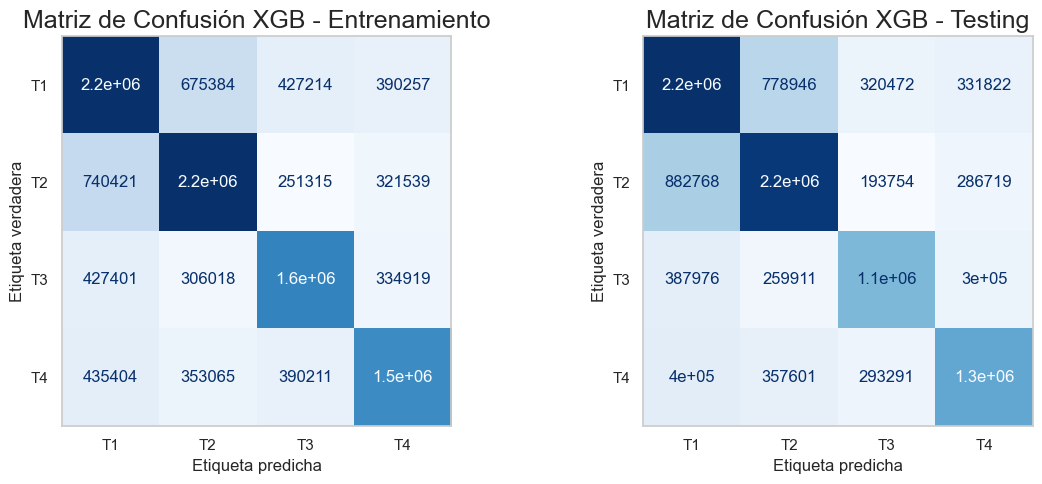

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión XGB - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=xgb_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión XGB - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 6.4 Predicciones con MLP

In [25]:
mlp_prediction_test = make_prediction(mlp_classifier, "test")

⏱️ MLPClassifier (test) predicho en 6.24s


In [26]:
mlp_prediction_train = make_prediction(mlp_classifier, "train")

⏱️ MLPClassifier (train) predicho en 6.56s


### 6.3.1 Guardar predicciones

In [ ]:
joblib.dump(mlp_prediction_test, "results/predictions/maiz/test/predicciones_mlp_test.pkl")

['results/predictions/maiz/test/predicciones_mlp_test_fix.pkl']

In [ ]:
joblib.dump(mlp_prediction_train, "results/predictions/maiz/train/predicciones_mlp_train.pkl")


['results/predictions/maiz/train/predicciones_mlp_train_fix.pkl']

### 6.3.2 Cargar predicciones

Test

In [ ]:
mlp_prediction_test = joblib.load('results/predictions/maiz/test/predicciones_mlp_test.pkl')

Train

In [ ]:
mlp_prediction_train = joblib.load('results/predictions/maiz/train/predicciones_mlp_train.pkl')

### 6.3.3 Resultados

In [29]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, mlp_prediction_train))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_prediction_test))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.46      0.51      0.48   3670873
           2       0.55      0.41      0.47   3495934
           3       0.45      0.51      0.48   2630850
           4       0.43      0.45      0.44   2679023

    accuracy                           0.47  12476680
   macro avg       0.47      0.47      0.47  12476680
weighted avg       0.48      0.47      0.47  12476680


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.47      0.54      0.50   3668800
           2       0.54      0.41      0.47   3533991
           3       0.44      0.46      0.45   2074592
           4       0.42      0.45      0.43   2325609

    accuracy                           0.47  11602992
   macro avg       0.47      0.46      0.46  11602992
weighted avg       0.47      0.47      0.47  11602992



In [31]:
mlp_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=mlp_prediction_train,
    labels=None,
    normalize=None,
)

In [32]:
mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_prediction_test,
    labels=None,
    normalize=None,
)

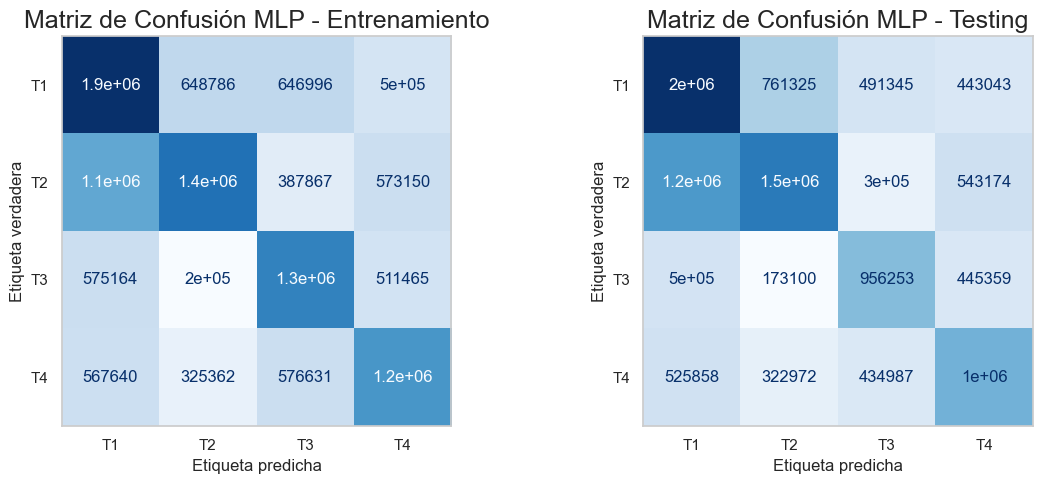

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de entrenamiento
disp_train = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión MLP - Entrenamiento')
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de testing
disp_test = ConfusionMatrixDisplay(confusion_matrix=mlp_cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión MLP - Testing')
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()

# 7. Evaluación de modelos

In [27]:
classifiers_names = ["knn", "rfc", "xgb", "mlp"]

In [42]:
predictions_train = [knn_prediction_train, rf_prediction_train, xgb_prediction_train, mlp_prediction_train]

In [43]:
predictions_test = [knn_prediction_test, rf_prediction_test, xgb_prediction_test, mlp_prediction_test]

In [44]:
cmxs_train = [knn_cm_train, rf_cm_train, xgb_cm_train, mlp_cm_train]

In [45]:
cmxs_test = [knn_cm_test, rf_cm_test, xgb_cm_test, mlp_cm_test]

Comparativo matrices de confusión entrenamiento

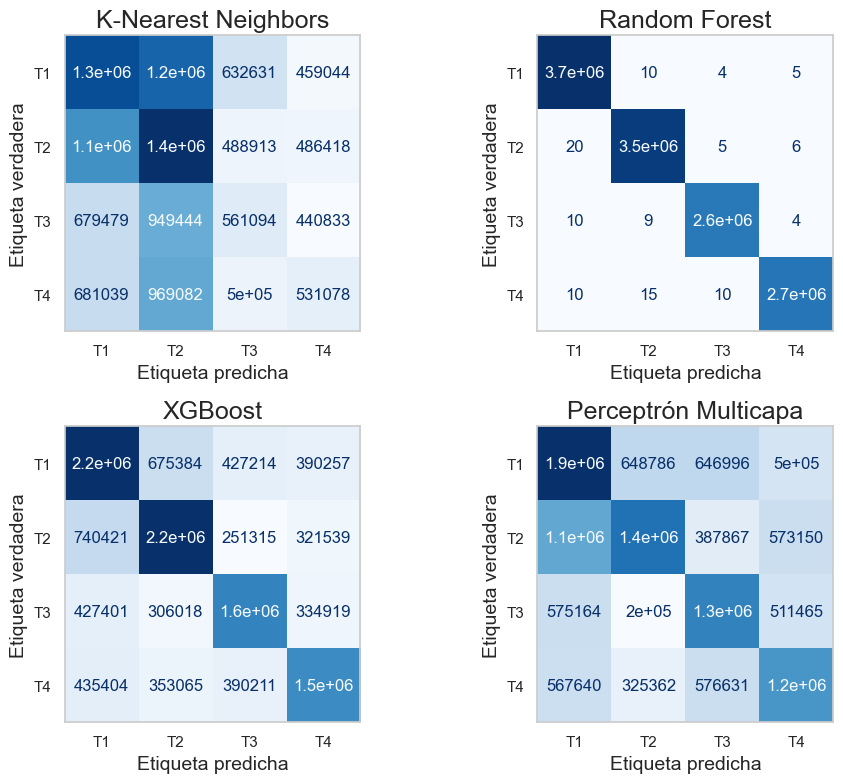

In [46]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_train, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Comparativo matrices de confusión test

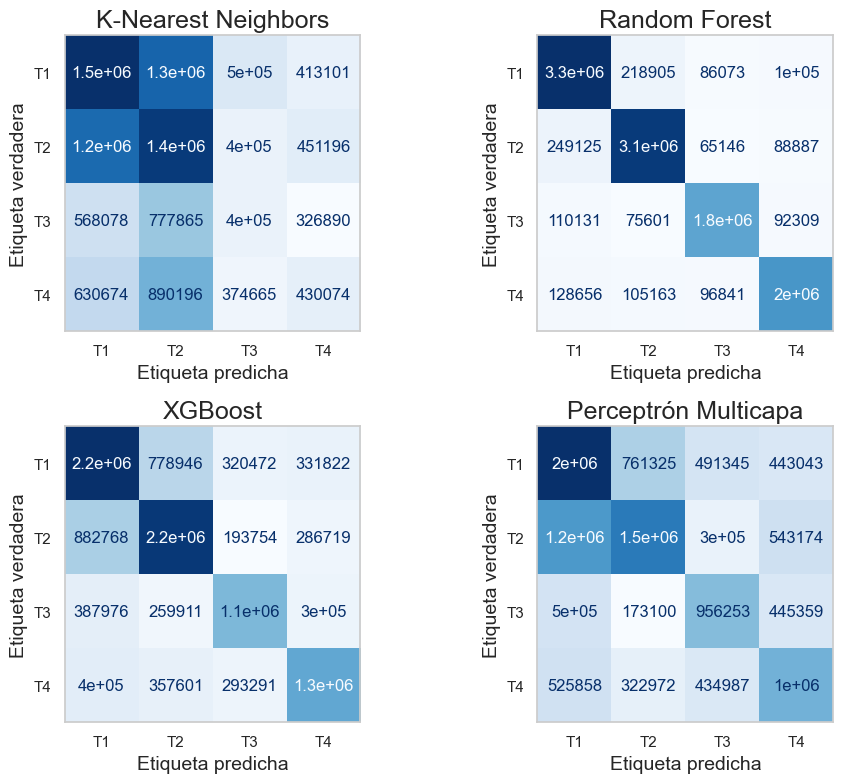

In [47]:
num_models = 4
ncols = 2
nrows = math.ceil(num_models / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

classifier_display_names = {
    "knn": "K-Nearest Neighbors",
    "rfc": "Random Forest",
    "xgb": "XGBoost",
    "mlp": "Perceptrón Multicapa"
}

for i, (cm, classifier_name) in enumerate(zip(cmxs_test, classifiers_names)):
    ax = axes[i]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{classifier_display_names.get(classifier_name, classifier_name)}")
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')
    tick_positions = np.arange(cm.shape[0])
    tick_labels = tick_positions + 1

for j in range(num_models, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Comparativo de métricas entrenamiento

In [48]:
results_list = []

for preds, classifier_name in zip(predictions_train, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_train_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_train_resampled, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_train_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_train_resampled, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.310395,0.305796,0.310395,0.304298,0.065263
rfc,0.999991,0.999991,0.999991,0.999991,0.999988
xgb,0.594993,0.595054,0.594993,0.594905,0.455300
mlp,0.470544,0.477456,0.470544,0.470458,0.290537


Comparativo de métricas testing

In [49]:
results_list = []

for preds, classifier_name in zip(predictions_test, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_test_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_test, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_test_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_test, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.325453,0.317225,0.325453,0.318026,0.068538
rfc,0.877915,0.877971,0.877915,0.877879,0.833730
xgb,0.586398,0.586502,0.586398,0.586030,0.435071
mlp,0.467758,0.473580,0.467758,0.467231,0.277854


# 8. Seleccionar hiperparámetros

In [21]:
def make_rand_grid_search(estimator, param_dist,):

    randomizedSearchCV = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=12,
    refit=True)
    
    return randomizedSearchCV

### 8.0.1 Guardar progreso

In [22]:
# Crear directorio para guardar modelos si no existe
for stage_dir in ['hyperparameter_tuning', 'best']:
    os.makedirs(f'models/maiz/{stage_dir}', exist_ok=True)

# Función para guardar progreso
def save_model_and_params(model, model_name, best_params, score, stage="hyperparameter_tuning"):
    """
    Guarda el modelo, sus mejores parámetros y el score obtenido
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Crear diccionario con toda la información
    model_info = {
        'model': model,
        'best_params': best_params,
        'best_score': score,
        'timestamp': timestamp,
        'model_name': model_name,
        'stage': stage
    }
    
    # Guardar en el directorio correspondiente
    save_path = f'models/maiz/{stage}/{model_name}_{timestamp}_fix.pkl'
    
    with open(save_path, 'wb') as f:
        pickle.dump(model_info, f)
    
    print(f"✅ Modelo {model_name} guardado en: {save_path}")
    return save_path

# Función para cargar modelo guardado
def load_model_info(filepath):
    """
    Carga un modelo guardado y su información
    """
    with open(filepath, 'rb') as f:
        model_info = pickle.load(f)
    
    print(f"📁 Modelo {model_info['model_name']} cargado desde: {filepath}")
    print(f"   - Score: {model_info['best_score']:.4f}")
    print(f"   - Timestamp: {model_info['timestamp']}")
    
    return model_info

### 8.0.2 Recuperación de progreso

Cargar modelos previamente guardados.

In [7]:
# Función para listar modelos guardados
def list_saved_models(stage="all"):
    """
    Lista todos los modelos guardados
    stage: 'hyperparameter_tuning', 'best', o 'all'
    """
    stages_to_check = []
    if stage == "all":
        stages_to_check = ["hyperparameter_tuning", "best"]
    else:
        stages_to_check = [stage]
    
    all_models = {}
    
    for stage_name in stages_to_check:
        path = f'models/{stage_name}'
        if os.path.exists(path):
            files = [f for f in os.listdir(path) if f.endswith('.pkl')]
            if files:
                all_models[stage_name] = files
                print(f"\n📁 Modelos en {stage_name}:")
                for i, file in enumerate(files, 1):
                    print(f"  {i}. {file}")
    
    if not all_models:
        print("❌ No se encontraron modelos guardados")
    
    return all_models

# Función para cargar el modelo más reciente de un tipo específico
def load_latest_model(model_name, stage="best"):
    """
    Carga el modelo más reciente de un tipo específico
    """
    path = f'models/{stage}'
    if not os.path.exists(path):
        print(f"❌ Directorio {path} no existe")
        return None
    
    # Buscar archivos que coincidan con el nombre del modelo
    files = [f for f in os.listdir(path) if f.startswith(model_name) and f.endswith('.pkl')]
    
    if not files:
        print(f"❌ No se encontraron modelos de tipo {model_name} en {stage}")
        return None
    
    # Ordenar por fecha (timestamp en el nombre del archivo)
    files.sort(reverse=True)  # Más reciente primero
    latest_file = files[0]
    
    return load_model_info(os.path.join(path, latest_file))

In [ ]:
# Si se necesita recuperar progreso
print("🔍 Buscando modelos guardados...")
saved_models = list_saved_models()

In [ ]:
# Para cargar un modelo específico:
model_info = load_latest_model("RandomForest", "hyperparameter_tuning")

## 8.1 Selección de muestra

Para acelerar la búsqueda de hiperparámetros, se trabaja con una muestra representativa del dataset de entrenamiento. Una vez encontrados los mejores parámetros, se entrena con el dataset completo.

In [23]:
# Configuración del tamaño de muestra para hiperparámetros
HYPERPARAMETER_SAMPLE_SIZE = 0.10  # 10% del dataset de entrenamiento
RANDOM_STATE = 42

print(f"Dataset original de entrenamiento: {X_train_scaled.shape[0]:,} muestras")

# Crear muestra estratificada manteniendo la proporción de clases
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train_scaled, 
    y_train_resampled,
    test_size=1-HYPERPARAMETER_SAMPLE_SIZE,  # Tomar solo el 10%
    stratify=y_train_resampled,  # Mantener proporción de clases
    random_state=RANDOM_STATE
)

# Para XGBoost versión codificada
y_train_sample_encoded = le.transform(y_train_sample)

print(f"Muestra para hiperparámetros: {X_train_sample.shape[0]:,} muestras ({HYPERPARAMETER_SAMPLE_SIZE*100:.1f}%)")
print(f"Reducción de tiempo estimada: ~{(1/HYPERPARAMETER_SAMPLE_SIZE):.1f}x más rápido")

# Verificar distribución de clases en la muestra
print("\nDistribución de clases en muestra para hiperparámetros:")
print(pd.Series(y_train_sample).value_counts().sort_index())

Dataset original de entrenamiento: 12,480,080 muestras
Muestra para hiperparámetros: 1,248,008 muestras (10.0%)
Reducción de tiempo estimada: ~10.0x más rápido

Distribución de clases en muestra para hiperparámetros:
1    366969
2    349747
3    263209
4    268083
Name: count, dtype: int64


## 8.2 KNeighbors - Búsqueda de hiperparámetros

In [15]:
knn_param_grid = [
    {
        'n_neighbors': np.arange(1, 10, 1), 
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    }
]

In [18]:
print("🔍 Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    knn_gridSearchCV = make_rand_grid_search(KNeighborsClassifier(n_jobs=-1), knn_param_grid)
    knn_gridSearchCV.fit(X_train_sample, y_train_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda KNN: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=knn_gridSearchCV,
        model_name="KNN",
        best_params=knn_gridSearchCV.best_params_,
        score=knn_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros KNN completada exitosamente")
    print(f"Best Score: {knn_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros KNN: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para KNN con muestra reducida...
Muestra: 1,248,008 registros
⏱️ Tiempo búsqueda KNN: 371.36 s (6.19 min)
✅ Modelo KNN guardado en: models/maiz/hyperparameter_tuning/KNN_20260414_161029_fix.pkl
✅ Búsqueda de hiperparámetros KNN completada exitosamente
Best Score: 0.4398


In [19]:
print("🎯 Mejores parámetros encontrados para KNN:")
print(knn_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {knn_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para KNN:
{'weights': 'uniform', 'n_neighbors': 8, 'metric': 'minkowski'}
Score de validación cruzada: 0.4398


In [20]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando KNN con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
knn_final = KNeighborsClassifier(n_jobs=-1, **knn_gridSearchCV.best_params_)
train_start = time.time()
knn_final.fit(X_train_scaled, y_train_resampled)
train_elapsed = time.time() - train_start

print(f"⏱️ Tiempo entrenamiento KNN final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=knn_final,
    model_name="KNN_final",
    best_params=knn_gridSearchCV.best_params_,
    score=knn_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo KNN final entrenado y guardado")


🚀 Entrenando KNN con dataset completo (12,480,080 muestras)...
⏱️ Tiempo entrenamiento KNN final: 40.01 s (0.67 min)
✅ Modelo KNN_final guardado en: models/maiz/best/KNN_final_20260414_182128_fix.pkl
✅ Modelo KNN final entrenado y guardado


### 8.2.1 Predicción

In [24]:
knn_y_test_pred = knn_final.predict(X_test_scaled)

In [25]:
knn_y_train_pred = knn_final.predict(X_train_scaled)

#### Guardar predicción

In [ ]:
joblib.dump(knn_y_test_pred, "results/predictions/maiz/test/best_predicciones_knn_test.pkl")

In [ ]:
joblib.dump(knn_y_train_pred, "results/predictions/maiz/train/best_predicciones_knn_train.pkl")

#### Cargar predicciones

In [ ]:
knn_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_knn_test.pkl')

In [ ]:
knn_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_knn_train.pkl')

### 8.2.2 Resultados

In [34]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, knn_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, knn_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.55      0.71      0.62   3669692
           2       0.61      0.59      0.60   3497475
           3       0.56      0.51      0.54   2632088
           4       0.61      0.46      0.52   2680825

    accuracy                           0.58  12480080
   macro avg       0.58      0.57      0.57  12480080
weighted avg       0.58      0.58      0.58  12480080


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.32      0.32      0.32   3668821
           2       0.30      0.30      0.30   3536037
           3       0.18      0.18      0.18   2074049
           4       0.20      0.20      0.20   2324085

    accuracy                           0.27  11602992
   macro avg       0.25      0.25      0.25  11602992
weighted avg       0.26      0.27      0.27  11602992



In [8]:
knn_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=knn_y_train_pred,
    labels=None,
    normalize=None,
)

In [9]:
knn_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=knn_y_test_pred,
    labels=None,
    normalize=None,
)

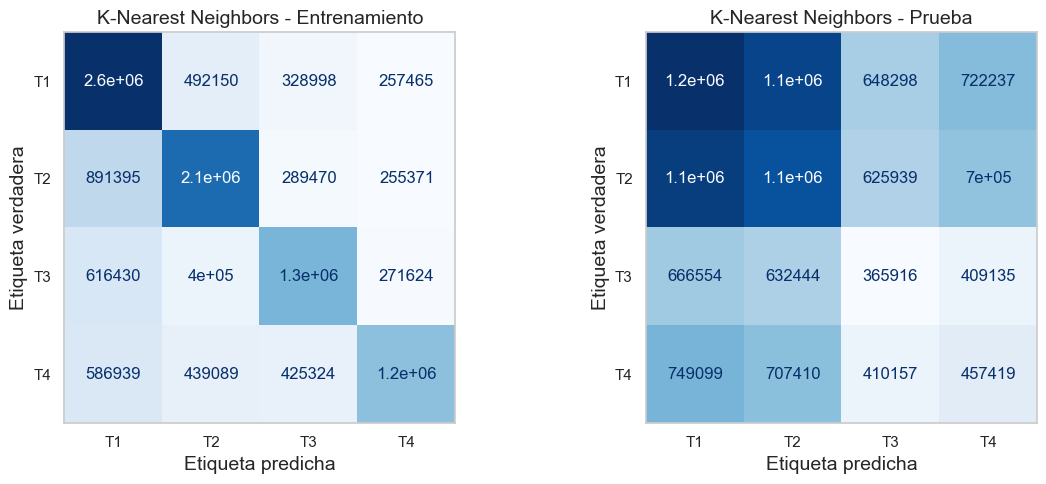

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [knn_cm_train, knn_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"K-Nearest Neighbors - {split}", fontsize=14)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.3 Random Forest - Búsqueda de hiperparámetros

In [38]:
rf_param_grid = [
    {
        'n_estimators': [100,150], 
        'min_samples_leaf': [1,2], 
        'min_samples_split': [2,4], 
        'max_depth': [None],
    }
]

In [ ]:
print("🔍 Iniciando búsqueda de hiperparámetros para Random Forest con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    rf_gridSearchCV = make_rand_grid_search(RandomForestClassifier(n_jobs=-1, random_state=12), rf_param_grid)
    rf_gridSearchCV.fit(X_train_sample, y_train_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda Random Forest: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=rf_gridSearchCV,
        model_name="RandomForest",
        best_params=rf_gridSearchCV.best_params_,
        score=rf_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros Random Forest completada exitosamente")
    print(f"Best Score: {rf_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros Random Forest: {e}")
    raise

In [11]:
save_path = save_model_and_params(
    model=rf_gridSearchCV,
    model_name="RandomForest",
    best_params=rf_gridSearchCV.best_params_,
    score=rf_gridSearchCV.best_score_,
    stage="hyperparameter_tuning"
)

print(f"✅ Búsqueda de hiperparámetros Random Forest completada exitosamente")
print(f"Best Score: {rf_gridSearchCV.best_score_:.4f}")

✅ Modelo RandomForest guardado en: models/hyperparameter_tuning/RandomForest_20251011_185728.pkl
✅ Búsqueda de hiperparámetros Random Forest completada exitosamente
Best Score: 0.7630


In [8]:
rf_best_params = {'n_estimators': 80, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}

In [ ]:
print("🎯 Mejores parámetros encontrados para Random Forest:")
# print(rf_gridSearchCV.best_params_)
# print(f"Score de validación cruzada: {rf_gridSearchCV.best_score_:.4f}")

# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando Random Forest con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
# rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_gridSearchCV.best_params_)
rf_final = RandomForestClassifier(n_jobs=-1, random_state=12, **rf_best_params)
train_start = time.time()
rf_final.fit(X_train_scaled, y_train_resampled)
train_elapsed = time.time() - train_start

# Guardar modelo final
final_save_path = save_model_and_params(
    model=rf_final,
    model_name="RandomForest_final",
    best_params=rf_gridSearchCV.best_params_,
    score=rf_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo Random Forest final entrenado y guardado")
print(f"⏱️ Tiempo entrenamiento Random Forest final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

In [ ]:
# Guardar modelo final
final_save_path = save_model_and_params(
    model=rf_final,
    model_name="RandomForest_final",
    best_params=rf_best_params,
    score=0.7630,
    stage="best"
)

In [ ]:
joblib.dump(rf_final, "models/best/rf_final_fix.pkl")

Cargar modelo

In [ ]:
rf_final = joblib.load('models/best/rf_final.pkl')

### 8.3.1 Predicción

In [13]:
rf_y_test_pred = rf_final.predict(X_test_scaled)

In [15]:
rf_y_train_pred = rf_final.predict(X_train_scaled)

#### Guardar predicción

In [14]:
joblib.dump(rf_y_test_pred, "results/predictions/maiz/test/best_predicciones_rf_test_fix.pkl")

['results/predictions/maiz/test/best_predicciones_rf_test_fix.pkl']

In [16]:
joblib.dump(rf_y_train_pred, "results/predictions/maiz/train/best_predicciones_rf_train_fix.pkl")

['results/predictions/maiz/train/best_predicciones_rf_train_fix.pkl']

#### Cargar predicciones

In [ ]:
rf_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_rf_test.pkl')

In [ ]:
rf_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_rf_train.pkl')

### 8.3.2 Resultados

In [17]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, rf_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, rf_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.98      0.98      0.98   3669692
           2       0.98      0.98      0.98   3497475
           3       0.98      0.98      0.98   2632088
           4       0.98      0.97      0.98   2680825

    accuracy                           0.98  12480080
   macro avg       0.98      0.98      0.98  12480080
weighted avg       0.98      0.98      0.98  12480080


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.68      0.72      0.70   3668821
           2       0.70      0.70      0.70   3536037
           3       0.68      0.65      0.67   2074049
           4       0.68      0.64      0.66   2324085

    accuracy                           0.69  11602992
   macro avg       0.68      0.68      0.68  11602992
weighted avg       0.69      0.69      0.69  11602992



In [13]:
rf_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=rf_y_train_pred,
    labels=None,
    normalize=None,
)

In [14]:
rf_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=rf_y_test_pred,
    labels=None,
    normalize=None,
)

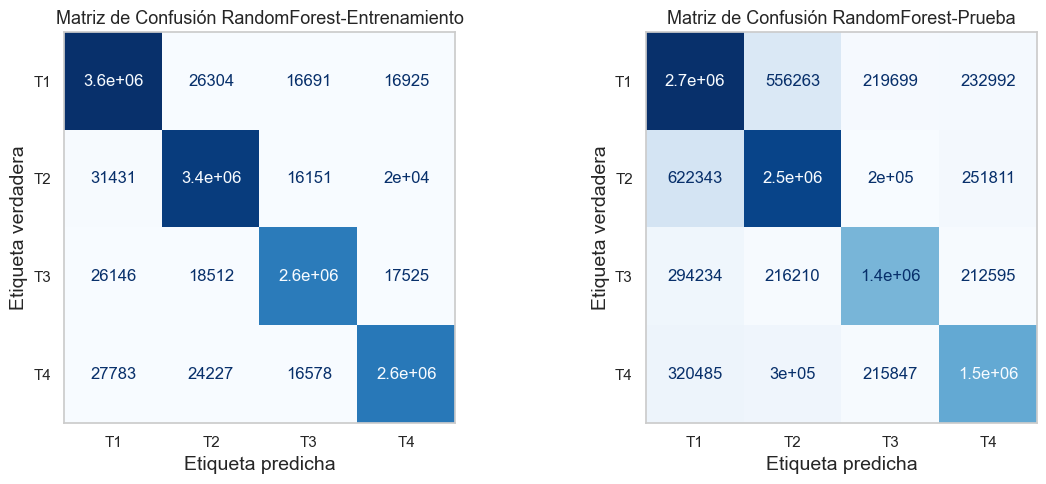

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [rf_cm_train, rf_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión RandomForest-{split}', fontsize=13)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.4 XGB - Búsqueda de hiperparámetros

In [40]:
xgb_param_grid = [
    {
    'n_estimators': [100, 150],           
    'max_depth': [5, 10],                   
    'learning_rate': [0.1, 0.2],        
    'subsample': [0.8, 1.0],             
    'colsample_bytree': [0.6, 0.8, 1.0],      
    'reg_alpha': [0, 0.1, 1],                 
    'reg_lambda': [1, 1.5, 2]                 
    }
]

In [41]:
print("🔍 Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    xgb_gridSearchCV = make_rand_grid_search(xgb.XGBClassifier(random_state=42), xgb_param_grid)
    xgb_gridSearchCV.fit(X_train_sample, y_train_sample_encoded)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda XGBoost: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=xgb_gridSearchCV,
        model_name="XGBoost",
        best_params=xgb_gridSearchCV.best_params_,
        score=xgb_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros XGBoost completada exitosamente")
    print(f"Best Score: {xgb_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error durante búsqueda de hiperparámetros XGBoost: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para XGBoost con muestra reducida...
Muestra: 1,248,008 registros
⏱️ Tiempo búsqueda XGBoost: 1825.11 s (30.42 min)
✅ Modelo XGBoost guardado en: models/maiz/hyperparameter_tuning/XGBoost_20260414_194448_fix.pkl
✅ Búsqueda de hiperparámetros XGBoost completada exitosamente
Best Score: 0.5245


In [42]:
print("🎯 Mejores parámetros encontrados para XGB:")
print(xgb_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {xgb_gridSearchCV.best_score_:.4f}")

print(f"\n🚀 Entrenando XGBoost con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
xgb_final = xgb.XGBClassifier(random_state=42, **xgb_gridSearchCV.best_params_)
train_start = time.time()
xgb_final.fit(X_train_scaled, y_train_encoded)
train_elapsed = time.time() - train_start
print(f"⏱️ Tiempo entrenamiento XGBoost final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=xgb_final,
    model_name="XGBoost_final",
    best_params=xgb_gridSearchCV.best_params_,
    score=xgb_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo XGBoost final entrenado y guardado")

🎯 Mejores parámetros encontrados para XGB:
{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 150, 'max_depth': 10, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Score de validación cruzada: 0.5245

🚀 Entrenando XGBoost con dataset completo (12,480,080 muestras)...
⏱️ Tiempo entrenamiento XGBoost final: 659.22 s (10.99 min)
✅ Modelo XGBoost_final guardado en: models/maiz/best/XGBoost_final_20260414_204157_fix.pkl
✅ Modelo XGBoost final entrenado y guardado


### 8.4.1 Predicción

In [43]:
xgb_y_test_pred = xgb_final.predict(X_test_scaled)

In [44]:
xgb_y_train_pred = xgb_final.predict(X_train_scaled)

#### Guardar predicciones

In [ ]:
joblib.dump(xgb_y_test_pred, "results/predictions/maiz/test/best_predicciones_xgb_test.pkl")

['results/predictions/maiz/test/best_predicciones_xgb_test_fix.pkl']

In [ ]:
joblib.dump(xgb_y_train_pred, "results/predictions/maiz/train/best_predicciones_xgb_train.pkl")

['results/predictions/maiz/train/best_predicciones_xgb_train_fix.pkl']

#### Cargar predicciones

In [ ]:
xgb_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_xgb_test.pkl')

In [ ]:
xgb_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_xgb_train.pkl')

### 8.4.2 Resultados

In [47]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_encoded, xgb_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test_encoded, xgb_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           0       0.53      0.64      0.58   3669692
           1       0.57      0.54      0.55   3497475
           2       0.54      0.49      0.51   2632088
           3       0.56      0.49      0.52   2680825

    accuracy                           0.55  12480080
   macro avg       0.55      0.54      0.54  12480080
weighted avg       0.55      0.55      0.55  12480080


Clasification Report - Prueba
              precision    recall  f1-score   support

           0       0.53      0.64      0.58   3668821
           1       0.56      0.54      0.55   3536037
           2       0.53      0.46      0.49   2074049
           3       0.55      0.47      0.51   2324085

    accuracy                           0.54  11602992
   macro avg       0.54      0.53      0.53  11602992
weighted avg       0.54      0.54      0.54  11602992



In [18]:
xgb_cm_train = confusion_matrix(
    y_true=y_train_encoded,
    y_pred=xgb_y_train_pred,
    labels=None,
    normalize=None,
)

In [19]:
xgb_cm_test = confusion_matrix(
    y_true=y_test_encoded,
    y_pred=xgb_y_test_pred,
    labels=None,
    normalize=None,
)

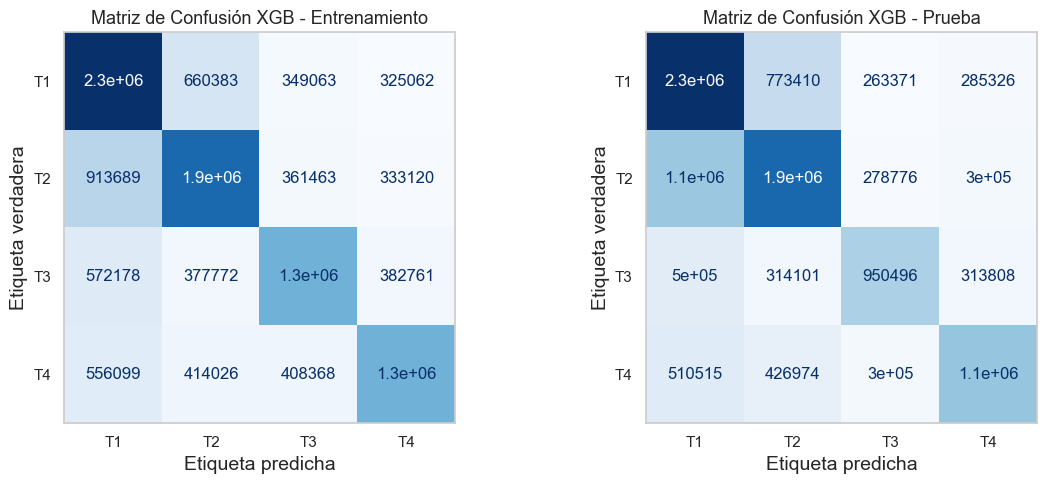

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [xgb_cm_train, xgb_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión XGB - {split}', fontsize=13)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.5 MLP - Búsqueda de hiperparámetros

In [20]:
mlp_param_grid = [
    {
        'hidden_layer_sizes': [(100,100,100), (128, 64, 32)], 
        'batch_size': [256],
        'learning_rate_init': [0.001],
        'alpha': [1e-4],
        'early_stopping' : [True]
    }
]

In [24]:
print("🔍 Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...")
print(f"Muestra: {X_train_sample.shape[0]:,} registros")

try:
    search_start = time.time()
    # Usar muestra para búsqueda de hiperparámetros
    mlp_gridSearchCV = make_rand_grid_search(MLPClassifier(), mlp_param_grid)
    mlp_gridSearchCV.fit(X_train_sample, y_train_sample)
    search_elapsed = time.time() - search_start

    print(f"⏱️ Tiempo búsqueda MLP: {search_elapsed:.2f} s ({search_elapsed/60:.2f} min)")
    
    # Guardar resultados de hiperparámetros
    save_path = save_model_and_params(
        model=mlp_gridSearchCV,
        model_name="MLP",
        best_params=mlp_gridSearchCV.best_params_,
        score=mlp_gridSearchCV.best_score_,
        stage="hyperparameter_tuning"
    )
    
    print(f"✅ Búsqueda de hiperparámetros MLP completada exitosamente")
    print(f"Best Score: {mlp_gridSearchCV.best_score_:.4f}")
    
except Exception as e:
    print(f"❌ Error during MLP hyperparameter search: {e}")
    raise

🔍 Iniciando búsqueda de hiperparámetros para MLP con muestra reducida...
Muestra: 1,248,008 registros
⏱️ Tiempo búsqueda MLP: 96585.15 s (1609.75 min)
✅ Modelo MLP guardado en: models/maiz/hyperparameter_tuning/MLP_20260425_011658_fix.pkl
✅ Búsqueda de hiperparámetros MLP completada exitosamente
Best Score: 0.4347


In [25]:
print("🎯 Mejores parámetros encontrados para MLP:")
print(mlp_gridSearchCV.best_params_)
print(f"Score de validación cruzada: {mlp_gridSearchCV.best_score_:.4f}")

🎯 Mejores parámetros encontrados para MLP:
{'learning_rate_init': 0.001, 'hidden_layer_sizes': (100, 100, 100), 'early_stopping': True, 'batch_size': 256, 'alpha': 0.0001}
Score de validación cruzada: 0.4347


In [26]:
# Ahora entrenar con dataset completo usando mejores parámetros
print(f"\n🚀 Entrenando MLP con dataset completo ({X_train_scaled.shape[0]:,} muestras)...")

# Crear modelo final con mejores parámetros
mlp_final = MLPClassifier(**mlp_gridSearchCV.best_params_)
train_start = time.time()
mlp_final.fit(X_train_scaled, y_train_resampled)
train_elapsed = time.time() - train_start

print(f"⏱️ Tiempo entrenamiento MLP final: {train_elapsed:.2f} s ({train_elapsed/60:.2f} min)")

# Guardar modelo final
final_save_path = save_model_and_params(
    model=mlp_final,
    model_name="MLP_final",
    best_params=mlp_gridSearchCV.best_params_,
    score=mlp_gridSearchCV.best_score_,
    stage="best"
)

print("✅ Modelo MLP final entrenado y guardado")


🚀 Entrenando MLP con dataset completo (12,480,080 muestras)...
⏱️ Tiempo entrenamiento MLP final: 100316.90 s (1671.95 min)
✅ Modelo MLP_final guardado en: models/maiz/best/MLP_final_20260426_101853_fix.pkl
✅ Modelo MLP final entrenado y guardado


### 8.5.1 Predicciones

In [27]:
mlp_y_test_pred = mlp_final.predict(X_test_scaled)

In [28]:
mlp_y_train_pred = mlp_final.predict(X_train_scaled)

#### Guardar predicciones

In [29]:
joblib.dump(mlp_y_test_pred, "results/predictions/maiz/test/best_predicciones_mlp_test_fix.pkl")

['results/predictions/maiz/test/best_predicciones_mlp_test_fix.pkl']

In [30]:
joblib.dump(mlp_y_train_pred, "results/predictions/maiz/train/best_predicciones_mlp_train_fix.pkl")

['results/predictions/maiz/train/best_predicciones_mlp_train_fix.pkl']

#### Cargar predicciones

In [35]:
mlp_y_test_pred = joblib.load('results/predictions/maiz/test/best_predicciones_mlp_test.pkl')

In [36]:
mlp_y_train_pred = joblib.load('results/predictions/maiz/train/best_predicciones_mlp_train.pkl')

### 8.5.2 Resultados

In [31]:
print("=" * 50)
print("Clasification Report - Entrenamiento")
print("=" * 50)
print(classification_report(y_train_resampled, mlp_y_train_pred))

print("\n" + "=" * 50)
print("Clasification Report - Prueba")
print("=" * 50)
print(classification_report(y_test, mlp_y_test_pred))

Clasification Report - Entrenamiento
              precision    recall  f1-score   support

           1       0.46      0.50      0.48   3669692
           2       0.48      0.50      0.49   3497475
           3       0.41      0.43      0.42   2632088
           4       0.45      0.35      0.39   2680825

    accuracy                           0.45  12480080
   macro avg       0.45      0.44      0.44  12480080
weighted avg       0.45      0.45      0.45  12480080


Clasification Report - Prueba
              precision    recall  f1-score   support

           1       0.47      0.52      0.50   3668821
           2       0.48      0.51      0.50   3536037
           3       0.40      0.39      0.40   2074049
           4       0.44      0.35      0.39   2324085

    accuracy                           0.46  11602992
   macro avg       0.45      0.44      0.44  11602992
weighted avg       0.46      0.46      0.46  11602992



In [32]:
mlp_cm_train = confusion_matrix(
    y_true=y_train_resampled,
    y_pred=mlp_y_train_pred,
    labels=None,
    normalize=None,
)

mlp_cm_test = confusion_matrix(
    y_true=y_test,
    y_pred=mlp_y_test_pred,
    labels=None,
    normalize=None,
)

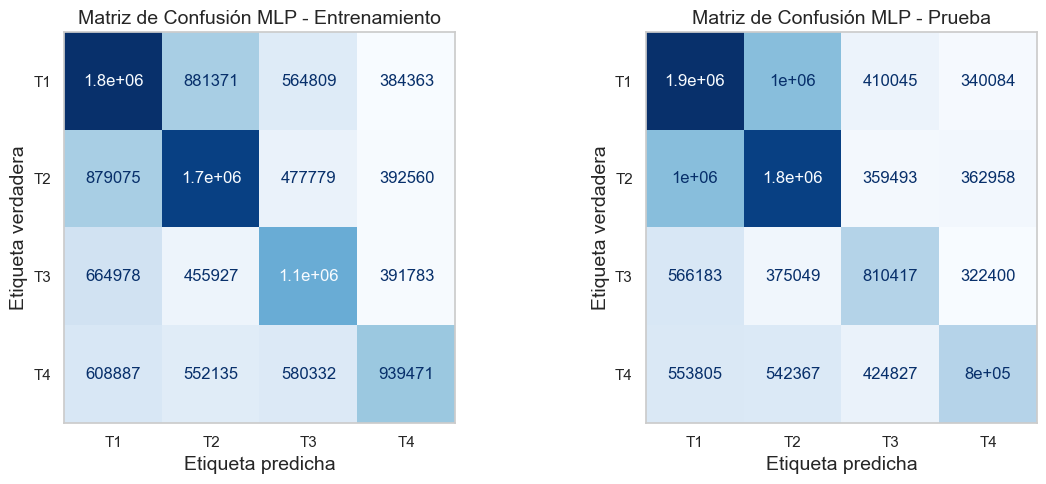

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

for ax, matriz, split in zip(
    axes,
    [mlp_cm_train, mlp_cm_test],
    ["Entrenamiento", "Prueba"],
):
    disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=tratamiento_labels)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Matriz de Confusión MLP - {split}', fontsize= 14)
    ax.grid(False)
    ax.set_xlabel('Etiqueta predicha')
    ax.set_ylabel('Etiqueta verdadera')

plt.tight_layout()
plt.show()

## 8.6 Evaluación de modelos optimizados

In [34]:
classifiers_names = ["knn", "rfc", "xgb", "mlp"]

In [35]:
predictions_train = [knn_y_train_pred, rf_y_train_pred, xgb_y_train_pred, mlp_y_train_pred]

In [36]:
predictions_test = [knn_y_test_pred, rf_y_test_pred, xgb_y_test_pred, mlp_y_test_pred]

Comparativo de métricas entrenamiento

In [37]:
results_list = []

for preds, classifier_name in zip(predictions_train, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_train_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_train_resampled, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_train_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_train_resampled, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.579355,0.583122,0.579355,0.575883,0.430349
rfc,0.979319,0.979326,0.979319,0.979316,0.972211
xgb,0.546959,0.548026,0.546959,0.545383,0.388310
mlp,0.452407,0.451957,0.452407,0.450619,0.261638


Comparativo de métricas testing

In [38]:
results_list = []

for preds, classifier_name in zip(predictions_test, classifiers_names):

    if classifier_name=='xgb':
        report_dict = classification_report(y_test_encoded, preds, output_dict=True)
    else:
        report_dict = classification_report(y_test, preds, output_dict=True)
    
    precision = report_dict['weighted avg']['precision']
    recall = report_dict['weighted avg']['recall']
    f1_score = report_dict['weighted avg']['f1-score']
    accuracy = report_dict['accuracy'] 

    # Kappa
    if classifier_name=='xgb':
        kappa = cohen_kappa_score(y_test_encoded, preds)
    else:
        kappa = cohen_kappa_score(y_test, preds)
    
    results_list.append({
        'Modelo': classifier_name,
        'Accuracy': accuracy,
        'Precision (Ponderada)': precision,
        'Recall (Ponderado)': recall,
        'F1-Score (Ponderado)': f1_score,
        'Kappa Score': kappa
    })

results_df = pd.DataFrame(results_list)

results_df = results_df.set_index('Modelo')

display(results_df.style.background_gradient(cmap='summer_r', axis=0))

,Accuracy,Precision (Ponderada),Recall (Ponderado),F1-Score (Ponderado),Kappa Score
Modelo,,,,,
knn,0.265570,0.264892,0.265570,0.265219,-0.000044
rfc,0.685915,0.685869,0.685915,0.685501,0.571273
xgb,0.542162,0.542869,0.542162,0.539803,0.371281
mlp,0.459971,0.457885,0.459971,0.457317,0.259724


# 9. Análisis de costos computacionales

## 9.1 Resultados Modelos Baseline

In [43]:
# Datos consolidados de las secciones anteriores y tiempos registrados
performance_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.265570, 0.685915, 0.542162, 0.459971],
    'Kappa_Score': [0.00044, 0.571273, 0.371281, 0.259724], 
    'Tiempo_Entrenamiento_Min': [0.7, 50, 4.1, 1672], # 42s, 50m, 4.1m, 125m
    'Tiempo_Texto': ['42 seg', '50 min', '4.1 min', '125 min']
}

df_perf = pd.DataFrame(performance_data)

# Mostrar tabla resumen
display(df_perf.style.background_gradient(subset=['Accuracy_Test', 'Kappa_Score'], cmap='Greens').background_gradient(subset=['Tiempo_Entrenamiento_Min'], cmap='Reds'))

,Modelo,Accuracy_Test,Kappa_Score,Tiempo_Entrenamiento_Min,Tiempo_Texto
0,KNN,0.265570,0.000440,0.700000,42 seg
1,Random Forest,0.685915,0.571273,50.000000,50 min
2,XGBoost,0.542162,0.371281,4.100000,4.1 min
3,MLP,0.459971,0.259724,1672.000000,125 min


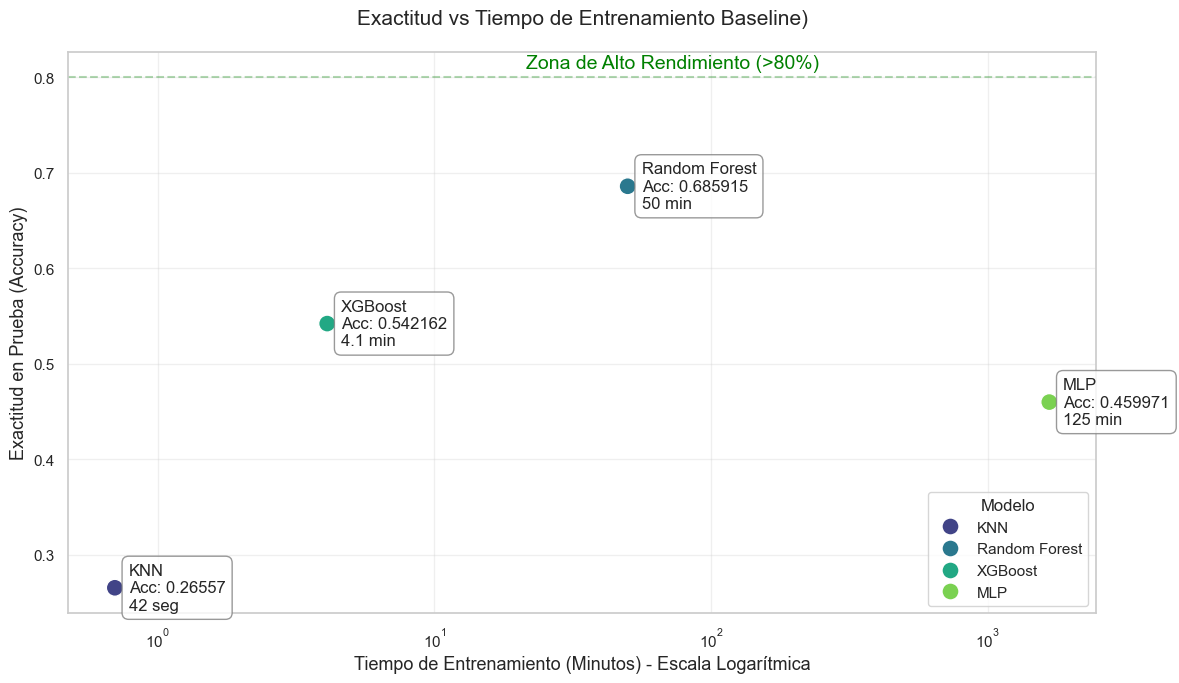

In [44]:
# Visualización de la Frontera de Pareto (Accuracy vs Tiempo)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Scatter plot
scatter = sns.scatterplot(
    data=df_perf, 
    x='Tiempo_Entrenamiento_Min', 
    y='Accuracy_Test', 
    s=150, 
    hue='Modelo', 
    palette='viridis'
)

# Escala logarítmica en X debido a la gran disparidad de tiempos (segundos vs días)
plt.xscale('log')

# Etiquetas y Títulos
plt.title('Exactitud vs Tiempo de Entrenamiento Baseline)', fontsize=15, pad=20)
plt.xlabel('Tiempo de Entrenamiento (Minutos) - Escala Logarítmica', fontsize=13)
plt.ylabel('Exactitud en Prueba (Accuracy)', fontsize=13)

# Hacer la grilla más transparente
plt.grid(alpha=0.3)

# Anotaciones
for i in range(df_perf.shape[0]):
    plt.annotate(
        f"{df_perf.Modelo[i]}\nAcc: {df_perf.Accuracy_Test[i]}\n{df_perf.Tiempo_Texto[i]}", 
        (df_perf.Tiempo_Entrenamiento_Min[i], df_perf.Accuracy_Test[i]),
        xytext=(10, 0), textcoords='offset points',
        va='center',  # Alineación vertical centrada con el símbolo
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
    )

# Marcar la región óptima (Alta exactitud, bajo tiempo)
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
plt.text(plt.xlim()[1] *0.1, 0.81, 'Zona de Alto Rendimiento (>80%)', color='green',
         ha='right', fontsize=14)

plt.tight_layout()
plt.show()

## 9.2 Resultados modelos optimizados

In [41]:
# Datos consolidados de las secciones anteriores y tiempos registrados
performance_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.265570, 0.685915, 0.542162, 0.459971],
    'Kappa_Score': [0.00044, 0.571273, 0.371281, 0.259724], 
    'Tiempo_Entrenamiento_Min': [0.6, 626, 11, 1672], # 40s, 626m, 11m, 1672m
    'Tiempo_Texto': ['40 seg', '626 min', '11 min', '1672 min']
}

df_perf = pd.DataFrame(performance_data)

# Mostrar tabla resumen
display(df_perf.style.background_gradient(subset=['Accuracy_Test', 'Kappa_Score'], cmap='Greens').background_gradient(subset=['Tiempo_Entrenamiento_Min'], cmap='Reds'))

,Modelo,Accuracy_Test,Kappa_Score,Tiempo_Entrenamiento_Min,Tiempo_Texto
0,KNN,0.265570,0.000440,0.600000,40 seg
1,Random Forest,0.685915,0.571273,626.000000,626 min
2,XGBoost,0.542162,0.371281,11.000000,11 min
3,MLP,0.459971,0.259724,1672.000000,1672 min


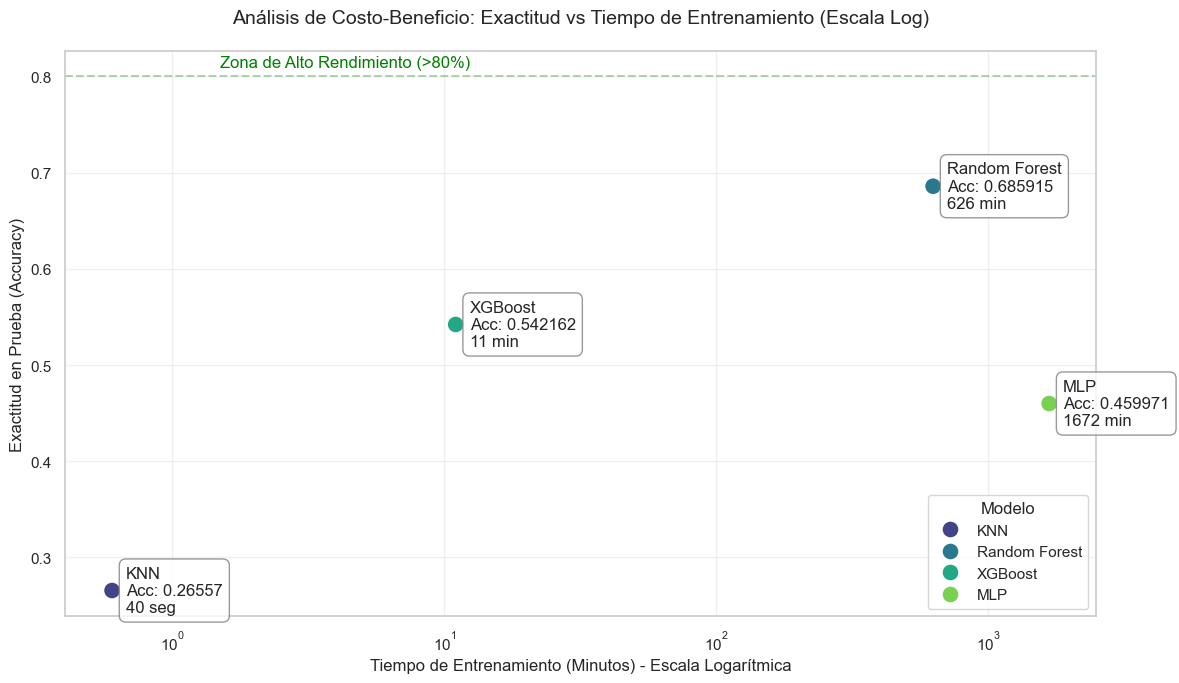

In [42]:
# Visualización de la Frontera de Pareto (Accuracy vs Tiempo)
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Scatter plot
scatter = sns.scatterplot(
    data=df_perf, 
    x='Tiempo_Entrenamiento_Min', 
    y='Accuracy_Test', 
    s=150, 
    hue='Modelo', 
    palette='viridis'
)

# Escala logarítmica en X debido a la gran disparidad de tiempos (segundos vs días)
plt.xscale('log')

# Etiquetas y Títulos
plt.title('Análisis de Costo-Beneficio: Exactitud vs Tiempo de Entrenamiento (Escala Log)', fontsize=14, pad=20)
plt.xlabel('Tiempo de Entrenamiento (Minutos) - Escala Logarítmica', fontsize=12)
plt.ylabel('Exactitud en Prueba (Accuracy)', fontsize=12)

# Hacer la grilla más transparente
plt.grid(alpha=0.3)

# Anotaciones
for i in range(df_perf.shape[0]):
    plt.annotate(
        f"{df_perf.Modelo[i]}\nAcc: {df_perf.Accuracy_Test[i]}\n{df_perf.Tiempo_Texto[i]}", 
        (df_perf.Tiempo_Entrenamiento_Min[i], df_perf.Accuracy_Test[i]),
        xytext=(10, 0), textcoords='offset points',
        va='center',  # Alineación vertical centrada con el símbolo
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8)
    )

# Marcar la región óptima (Alta exactitud, bajo tiempo)
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
plt.text(1.5, 0.81, 'Zona de Alto Rendimiento (>80%)', color='green')

plt.tight_layout()
plt.show()

In [47]:
# Datos actualizados con tiempos de búsqueda y entrenamiento proporcionados
optimization_data = {
    'Modelo': ['KNN', 'Random Forest', 'XGBoost', 'MLP'],
    'Accuracy_Test': [0.265570, 0.685915, 0.542162, 0.459971],
    'Tiempo_Busqueda_Min': [0.6, 626, 11, 1672],        # 40s, 626m, 11m, 1672m
    'Tiempo_Entrenamiento_Min': [6.1, 256, 30.4, 1610],  # 6.1m, 256m, 30.4m, 1610m
}

df_opt = pd.DataFrame(optimization_data)
df_opt['Tiempo_Total_Min'] = df_opt['Tiempo_Busqueda_Min'] + df_opt['Tiempo_Entrenamiento_Min']
df_opt['Tiempo_Total_Texto'] = [
    '~6 min', '882 min (~15h)', '41.4 min', '3282 min (~55h)'
]

# Mostrar tabla detallada
print("Tabla de Costos Computacionales (Búsqueda + Entrenamiento Final):")
display(df_opt.style.background_gradient(subset=['Accuracy_Test'], cmap='Greens')
                   .background_gradient(subset=['Tiempo_Total_Min'], cmap='Reds'))

Tabla de Costos Computacionales (Búsqueda + Entrenamiento Final):


,Modelo,Accuracy_Test,Tiempo_Busqueda_Min,Tiempo_Entrenamiento_Min,Tiempo_Total_Min,Tiempo_Total_Texto
0,KNN,0.265570,0.600000,6.100000,6.700000,~6 min
1,Random Forest,0.685915,626.000000,256.000000,882.000000,882 min (~15h)
2,XGBoost,0.542162,11.000000,30.400000,41.400000,41.4 min
3,MLP,0.459971,1672.000000,1610.000000,3282.000000,3282 min (~55h)


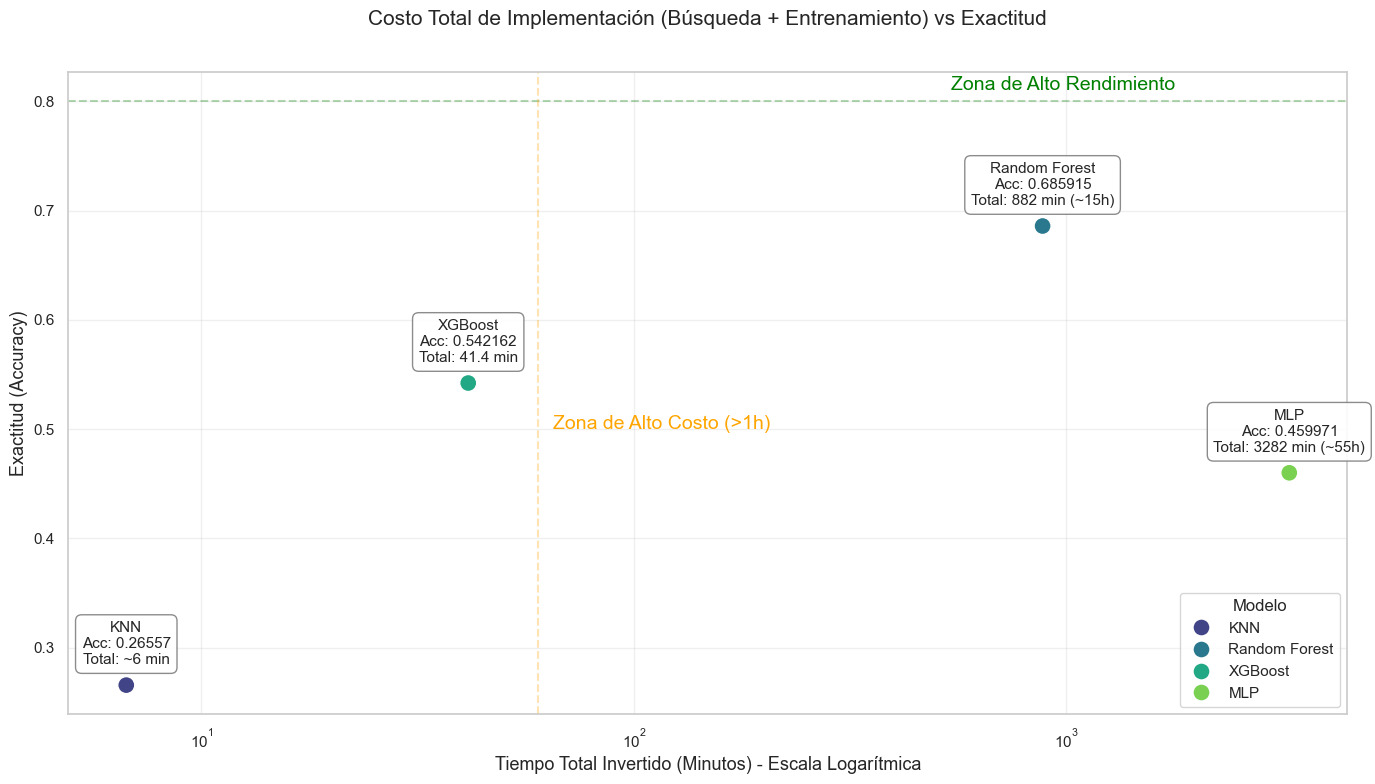

In [49]:
# Visualización: Costo Total (Búsqueda + Entrenamiento) vs Accuracy
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Scatter plot
sns.scatterplot(
    data=df_opt, 
    x='Tiempo_Total_Min', 
    y='Accuracy_Test', 
    s=150, 
    hue='Modelo', 
    palette='viridis',
    zorder=5
)

# Escala logarítmica para visualizar mejor las diferencias extremas
plt.xscale('log')

# Etiquetas
plt.title('Costo Total de Implementación (Búsqueda + Entrenamiento) vs Exactitud', fontsize=15, pad=34)
plt.xlabel('Tiempo Total Invertido (Minutos) - Escala Logarítmica', fontsize=13)
plt.ylabel('Exactitud (Accuracy)', fontsize=13)

# Grilla más transparente
plt.grid(alpha=0.3)

# Anotaciones
for i in range(df_opt.shape[0]):
    plt.annotate(
        f"{df_opt.Modelo[i]}\nAcc: {df_opt.Accuracy_Test[i]}\nTotal: {df_opt.Tiempo_Total_Texto[i]}", 
        (df_opt.Tiempo_Total_Min[i], df_opt.Accuracy_Test[i]),
        xytext=(0, 15), textcoords='offset points', ha='center',
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9)
    )

# Zona de eficiencia
plt.axhline(y=0.8, color='green', linestyle='--', alpha=0.3)
plt.axvline(x=60, color='orange', linestyle='--', alpha=0.3) # Línea de 1 hora
# Posicionar etiquetas dentro del gráfico con letra más grande
plt.text(plt.xlim()[1] * 0.4, 0.81, 'Zona de Alto Rendimiento', color='green', ha='right', fontsize=14)
plt.text(65, 0.5, 'Zona de Alto Costo (>1h)', color='orange', ha='left', fontsize=14)

plt.tight_layout()
plt.show()